# Plots for figure 2

Read in all necessary packages:

In [16]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scvelo as scv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import singlecellmultiomics.bamProcessing.bamToRNACounts
import loompy
import collections

In [17]:
dpi=80

In [18]:
scv.settings.verbosity = 3 # show errors(0), warnings(1), info(2), hints(3)
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

trans = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)
k4 = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
k27 = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)

scv.settings.presenter_view = True  # set max width size for presenter view
sc.set_figure_params(dpi=dpi, color_map = trans)



scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.19.2 scipy==1.8.0 pandas==1.4.1 scikit-learn==1.0.2 statsmodels==0.13.2 python-igraph==0.9.9 pynndescent==0.5.6


# Load the dataset + reorganise

In [4]:
#import loom in adata
#adata = sc.read_h5ad('data/20230704_adata_all.h5ad')
#adata

In [5]:
metadata = pd.read_csv('data/20230704_adata_obs_celltyping.csv', sep = '\t', index_col = 0)
metadata.head(2)

,batch,day,replicates,mark,day_rep,dataset,hour,celltype,celltype_general,lineage,...,S_score,G2M_score,phase,enrichment,coverage,QC,pseudotime,pseudotime2,X_umap-0,X_umap-1
index,,,,,,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_341,PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1,Gastd5,rep2,H3K27me3,Gastd5_rep2,old,120h,Endothelium,Haemogenic,Mesoderm,...,-0.025686,-0.040124,G1,78.808261,38.540,good,56.601980,51.219790,-0.218837,12.208694
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1,Gastd5,rep2,H3K27me3,Gastd5_rep2,old,120h,Neural Progenitors,Neural Progenitors,Ectoderm,...,0.113965,0.081538,S,70.389349,34.978,good,30.236847,14.116035,0.428891,3.563945


In [6]:
k4_counts = sc.read_h5ad('data/allsamples_promoterlevel_K4me3_counts.h5ad')
k4_counts

AnnData object with n_obs × n_vars = 23040 × 62142
    obs: 'barcode_nla', 'barcode_vasa', 'barcodes', 'index', 'index_nla', 'index_vasa', 'plate_batch', 'sample'
    var: 'ID', 'NOGS_olap', 'Symbol', 'chr', 'end', 'geneID', 'gene_strand', 'name', 'score', 'start', 'strand'

In [7]:
barcodes = pd.read_csv("/Users/m.blotenburg/Documents/Projects/Helena/data/VASAbarcodes.csv", sep = '\t', header = None, index_col=0, squeeze=True).to_dict()
barcodes = {y:x for x,y in barcodes.items()}
k4_counts.var.index=k4_counts.var['name']
k4_counts.obs.index="PZ-MB-TChIC-" + (k4_counts.obs['sample']).astype(str) + '_' + (k4_counts.obs['barcode_vasa'].map(lambda x: barcodes[x])).astype(str)
k4_counts.obs['cellnames']=k4_counts.obs.index


In [8]:
k4_counts.var['promoter'] = [ob.split(':')[2] for ob in k4_counts.var.index]

In [9]:
k4_counts.obs.head(2)

,barcode_nla,barcode_vasa,barcodes,index,index_nla,index_vasa,plate_batch,sample,cellnames
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1,ACACACTA,CGTCTAAT,ACACACTA,Gastd3-rep3-H3K4me3-1::ACACACTA,Gastd3-rep3-H3K4me3-1:ACACACTA,Gastd3-rep3-H3K4me3-1:CGTCTAAT,0,Gastd3-rep3-H3K4me3-1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,ACACATAG,AGACTCGT,ACACATAG,Gastd3-rep3-H3K4me3-1::ACACATAG,Gastd3-rep3-H3K4me3-1:ACACATAG,Gastd3-rep3-H3K4me3-1:AGACTCGT,0,Gastd3-rep3-H3K4me3-1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2


In [10]:
k4_counts.var.head(2)

,ID,NOGS_olap,Symbol,chr,end,geneID,gene_strand,name,score,start,strand,promoter
name,,,,,,,,,,,,
P_4585:Kitl:1,P_4585,I:133774;E:184385;E:184386;E:184387;E:184388;E...,Kitl,10,100018772,ENSMUSG00000019966,+,P_4585:Kitl:1,0,100013772,.,1
P_4586:Kitl:2,P_4586,I:133780;I:133781;I:133782;I:133783;E:184390;E...,Kitl,10,100091055,ENSMUSG00000019966,+,P_4586:Kitl:2,0,100086055,.,2


In [11]:
print(k4_counts.obs.shape)
print(k4_counts.var.shape)

(23040, 9)
(62142, 12)


In [12]:
k4_counts.var['promoter'].unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '3648991'], dtype=object)

In [13]:
k4_counts[:,k4_counts.var['promoter'] == '3648991'].var

,ID,NOGS_olap,Symbol,chr,end,geneID,gene_strand,name,score,start,strand,promoter
name,,,,,,,,,,,,
P_60083:MGI:3648991:1,P_60083,I:119458;A:70688;A:70689,MGI,9,72694548,ENSMUSG00000102573,+,P_60083:MGI:3648991:1,0,72689548,.,3648991


In [14]:
var = k4_counts.var
var.head(2)

,ID,NOGS_olap,Symbol,chr,end,geneID,gene_strand,name,score,start,strand,promoter
name,,,,,,,,,,,,
P_4585:Kitl:1,P_4585,I:133774;E:184385;E:184386;E:184387;E:184388;E...,Kitl,10,100018772,ENSMUSG00000019966,+,P_4585:Kitl:1,0,100013772,.,1
P_4586:Kitl:2,P_4586,I:133780;I:133781;I:133782;I:133783;E:184390;E...,Kitl,10,100091055,ENSMUSG00000019966,+,P_4586:Kitl:2,0,100086055,.,2


In [19]:
dpi_fig = 80

sns.set_style('white')
sns.set_context('talk')
sns.set_style('ticks')

<AxesSubplot:xlabel='promoter', ylabel='Count'>

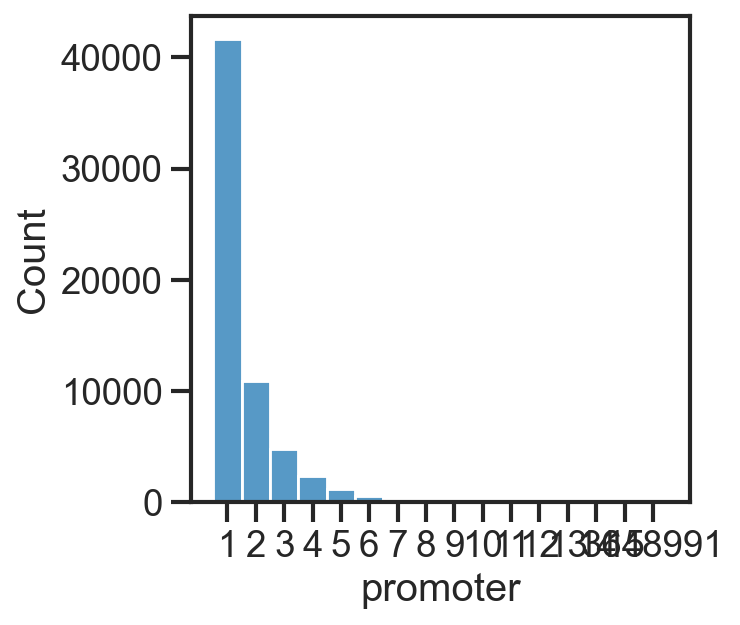

In [20]:
sns.histplot(var['promoter'])

<AxesSubplot:xlabel='gene_strand', ylabel='Count'>

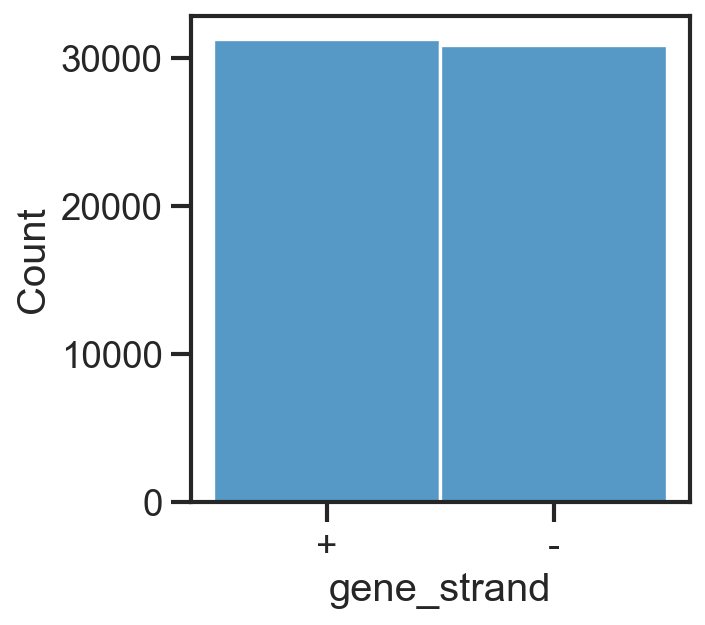

In [21]:
sns.histplot(var['gene_strand'])

<AxesSubplot:xlabel='chr', ylabel='Count'>

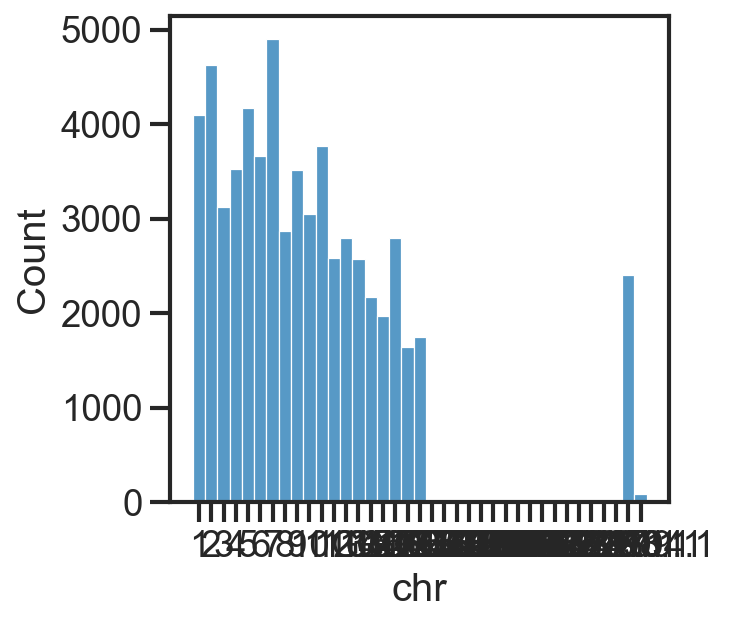

In [22]:
sns.histplot(var['chr'])

In [23]:
k4 = pd.DataFrame(k4_counts.X.toarray())
k4.columns = k4_counts.var.index
k4.index = k4_counts.obs.index
k4.head(2)

name,P_4585:Kitl:1,P_4586:Kitl:2,P_69684:Gm35533:1,P_69483:Gm47627:1,P_69082:Gm8689:1,P_68903:Gm9476:1,P_69431:Gm47673:1,P_22470:Tmtc3:1,P_4593:Cep290:1,P_4594:Cep290:2,...,P_57298:Gm29535:1,P_58670:Gm29533:1,P_59192:Gm29534:1,P_54131:Gm21874:1,P_59280:Gm28849:1,P_58048:Gm28848:1,P_59525:Gm28846:1,P_58238:Gm29471:1,P_57683:Gm29475:1,P_52670:Gm20821:1
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
k4.columns = k4.columns.str.split(':', expand=True)
k4.columns = k4.columns.droplevel([0,3])

In [25]:
k4.head(2)

Kitl      Gm35533 Gm47627 Gm8689 Gm9476  \
                                       1    2       1       1      1      1   
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1  0.0  0.0     0.0     0.0    0.0    0.0   
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2  1.0  0.0     0.0     0.0    0.0    0.0   

                                    Gm47673 Tmtc3 Cep290       ... Gm29535  \
                                          1     1      1    2  ...       1   
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1     0.0   0.0    0.0  0.0  ...     0.0   
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2     0.0   0.0    0.0  0.0  ...     0.0   

                                    Gm29533 Gm29534 Gm21874 Gm28849 Gm28848  \
                                          1       1       1       1       1   
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1     0.0     0.0     0.0     0.0     0.0   
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2     0.0     0.0     0.0     0.0     0.0   

                                    Gm28846 Gm29471 Gm29475 Gm20821  
                                          1       1       1       1  
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1     0.0     0.0     0.0     0.0  
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2     0.0     0.0     0.0     0.0  

[2 rows x 62142 columns]

Text(0.5, 1.0, 'sum genes')

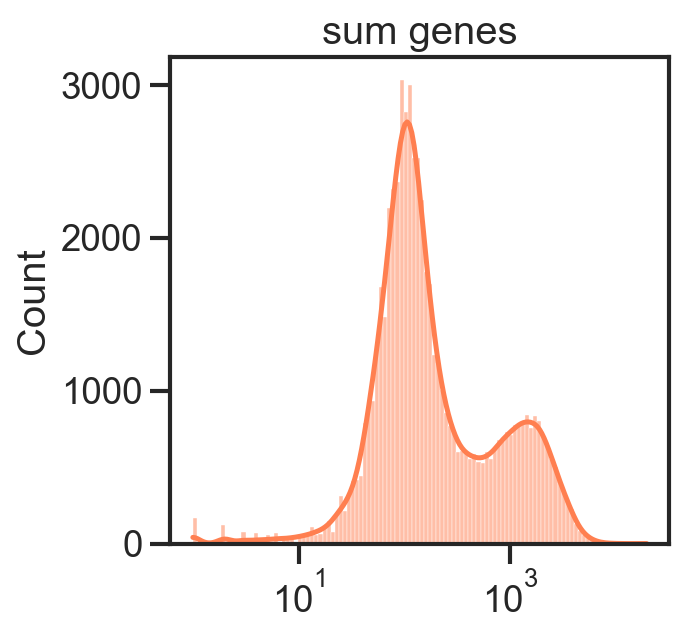

In [26]:
sum_genes = k4.sum(axis=0).sort_values()

sum_genes = sum_genes[sum_genes != 0]

sns.histplot(sum_genes, kde = True, log_scale=True, color = 'coral')
plt.title('sum genes')

In [250]:
plot_sep

,level_0,level_1,counts
0,Trav3-2,1,1.0
1,Gm37903,1,1.0
2,Trav6-7-dv9,1,1.0
3,Gm28920,1,1.0
4,Gm18187,1,1.0
...,...,...,...
61207,Gm37376,1,8247.0
61208,Cspp1,1,9016.0
61209,Malat1,2,9241.0
61210,Ier2,1,9403.0


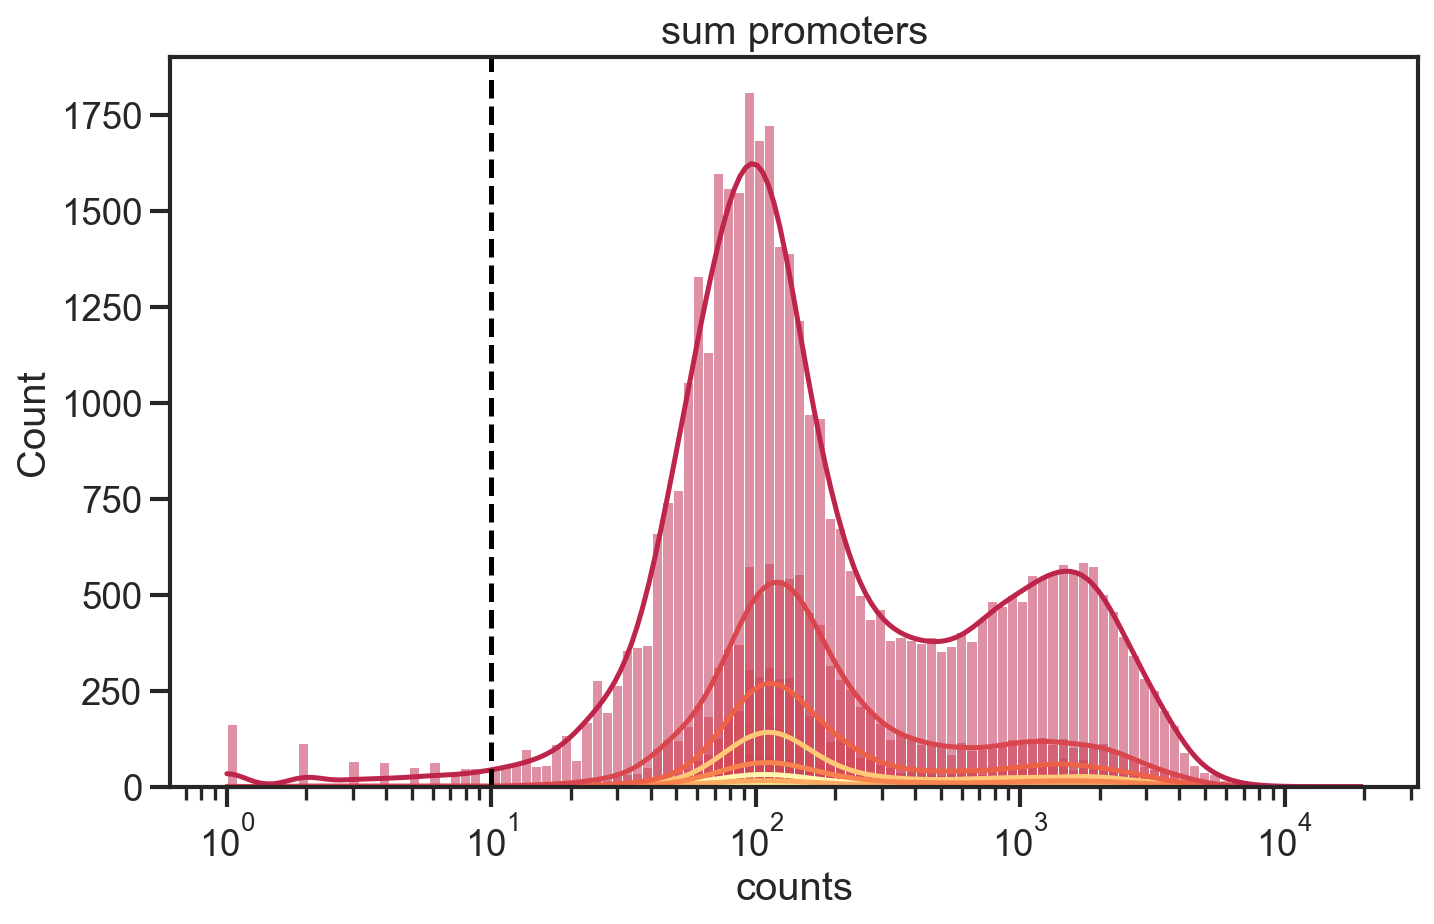

In [379]:
plot_sep = pd.DataFrame(sum_genes).reset_index().rename(columns = {0:'counts'})

plt.figure(figsize=(10,6))
sns.histplot(data = plot_sep, x = 'counts', kde = True, 
             log_scale=True, hue = 'level_1', palette = 'Spectral')
plt.title('sum promoters')
plt.legend([], frameon=False)
plt.axvline(10, color = 'black', linestyle = '--')


In [28]:
sum_cells = k4.sum(axis=1).sort_values()

sum_cells = sum_cells[sum_cells != 0]

Text(0.5, 1.0, 'sum cells')

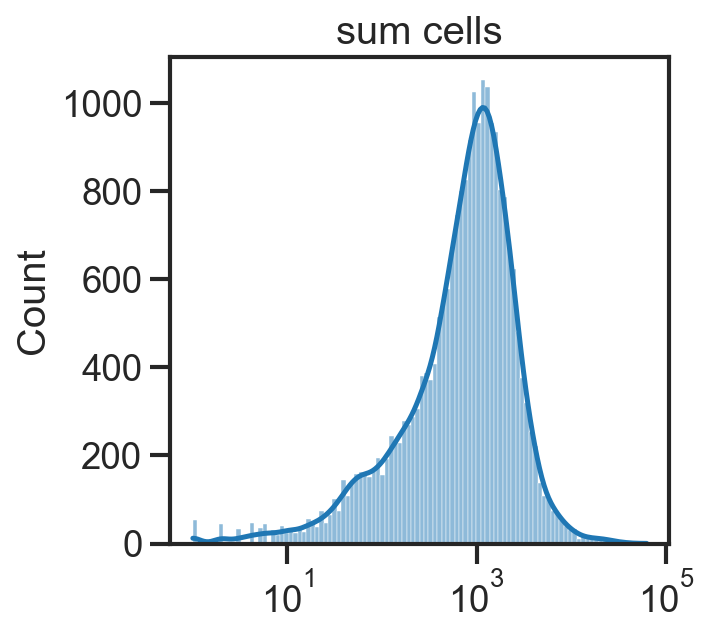

In [29]:
sns.histplot(sum_cells, kde = True, log_scale = True)
plt.title('sum cells')

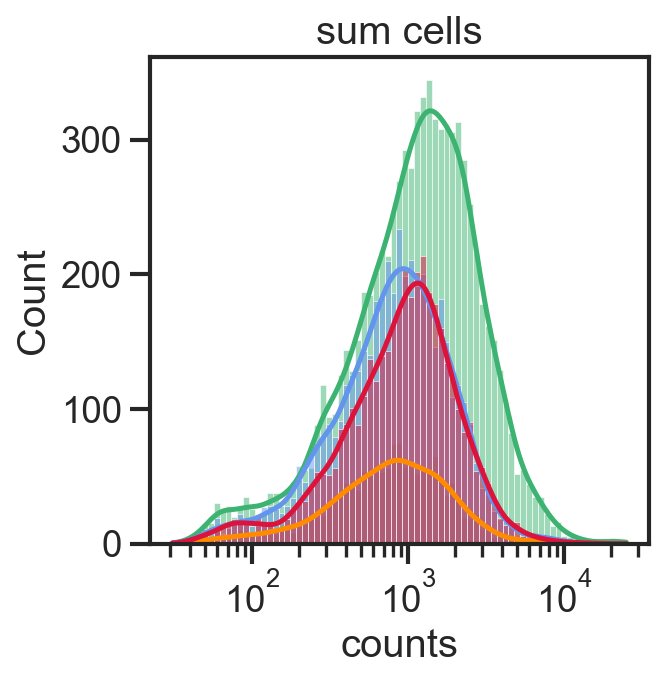

In [30]:
plot_cells = pd.DataFrame(sum_cells).rename(columns = {0:'counts'})
k4_counts.obs['lineage'] = metadata['lineage']
plot_cells['lineage'] = k4_counts.obs['lineage']

sns.histplot(plot_cells, x = 'counts', kde = True, 
             log_scale = True,hue = 'lineage', 
             palette = ['crimson','cornflowerblue','mediumseagreen','darkorange'])
plt.title('sum cells')
plt.legend([], frameon=False)

In [43]:
#k4_sub = k4.iloc[0:1000]

In [282]:
k4 = k4.loc[:,sum_genes[sum_genes > 10].index]

In [283]:
k4_binary = np.sign(k4)

In [284]:
k4_binary.columns.names = ['gene','promoter']


In [285]:
k4_prom = k4_binary.droplevel(0, axis = 1).groupby('promoter', axis=1).sum()

In [286]:
k4_prom.index.names = ['cell']


In [287]:
k4_prom

promoter,1,10,11,12,13,14,15,2,3,3648991,4,5,6,7,8,9
cell,,,,,,,,,,,,,,,,
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1,11.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1021.0,3.0,1.0,1.0,0.0,0.0,0.0,232.0,104.0,0.0,37.0,26.0,12.0,4.0,4.0,1.0
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,954.0,2.0,0.0,0.0,0.0,0.0,0.0,198.0,110.0,0.0,44.0,24.0,16.0,5.0,3.0,1.0
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,544.0,1.0,0.0,0.0,0.0,0.0,0.0,114.0,53.0,0.0,35.0,11.0,4.0,3.0,1.0,0.0
PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,1162.0,1.0,2.0,0.0,0.0,0.0,0.0,267.0,115.0,0.0,53.0,30.0,9.0,4.0,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,1291.0,1.0,1.0,1.0,0.0,0.0,0.0,282.0,125.0,0.0,62.0,35.0,18.0,10.0,7.0,4.0
PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1104.0,0.0,1.0,0.0,0.0,0.0,0.0,266.0,111.0,0.0,51.0,34.0,8.0,6.0,5.0,1.0
PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,669.0,1.0,1.0,0.0,0.0,0.0,0.0,160.0,76.0,0.0,26.0,20.0,7.0,1.0,1.0,1.0


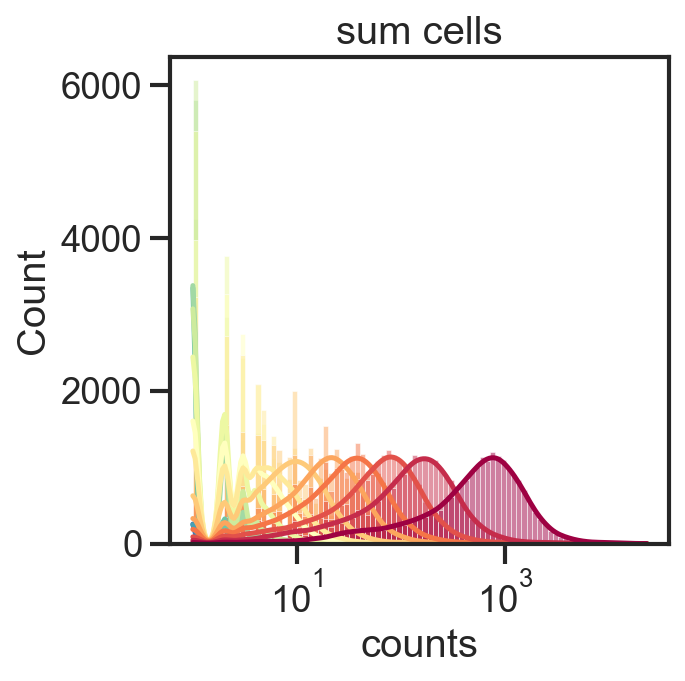

In [288]:
plot_prom = pd.DataFrame(k4_prom.unstack()).rename(columns={0:'counts'}).reset_index()

plot_prom = plot_prom[plot_prom['counts'] != 0]
plot_prom = plot_prom[plot_prom['counts'] != 0]
plot_prom['promoter'] = plot_prom['promoter'].astype(int)
plot_prom = plot_prom[plot_prom['promoter'] < 20]

sns.histplot(plot_prom, x = 'counts', kde = True, 
             log_scale = True,hue = 'promoter', palette = 'Spectral',
             )
plt.title('sum cells')
plt.legend([], frameon=False)



In [289]:
plot_prom

,promoter,cell,counts
0,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1,11.0
1,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1021.0
2,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,954.0
3,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,544.0
4,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,1162.0
...,...,...,...
368635,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,4.0
368636,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1.0
368637,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,1.0
368638,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_383,8.0


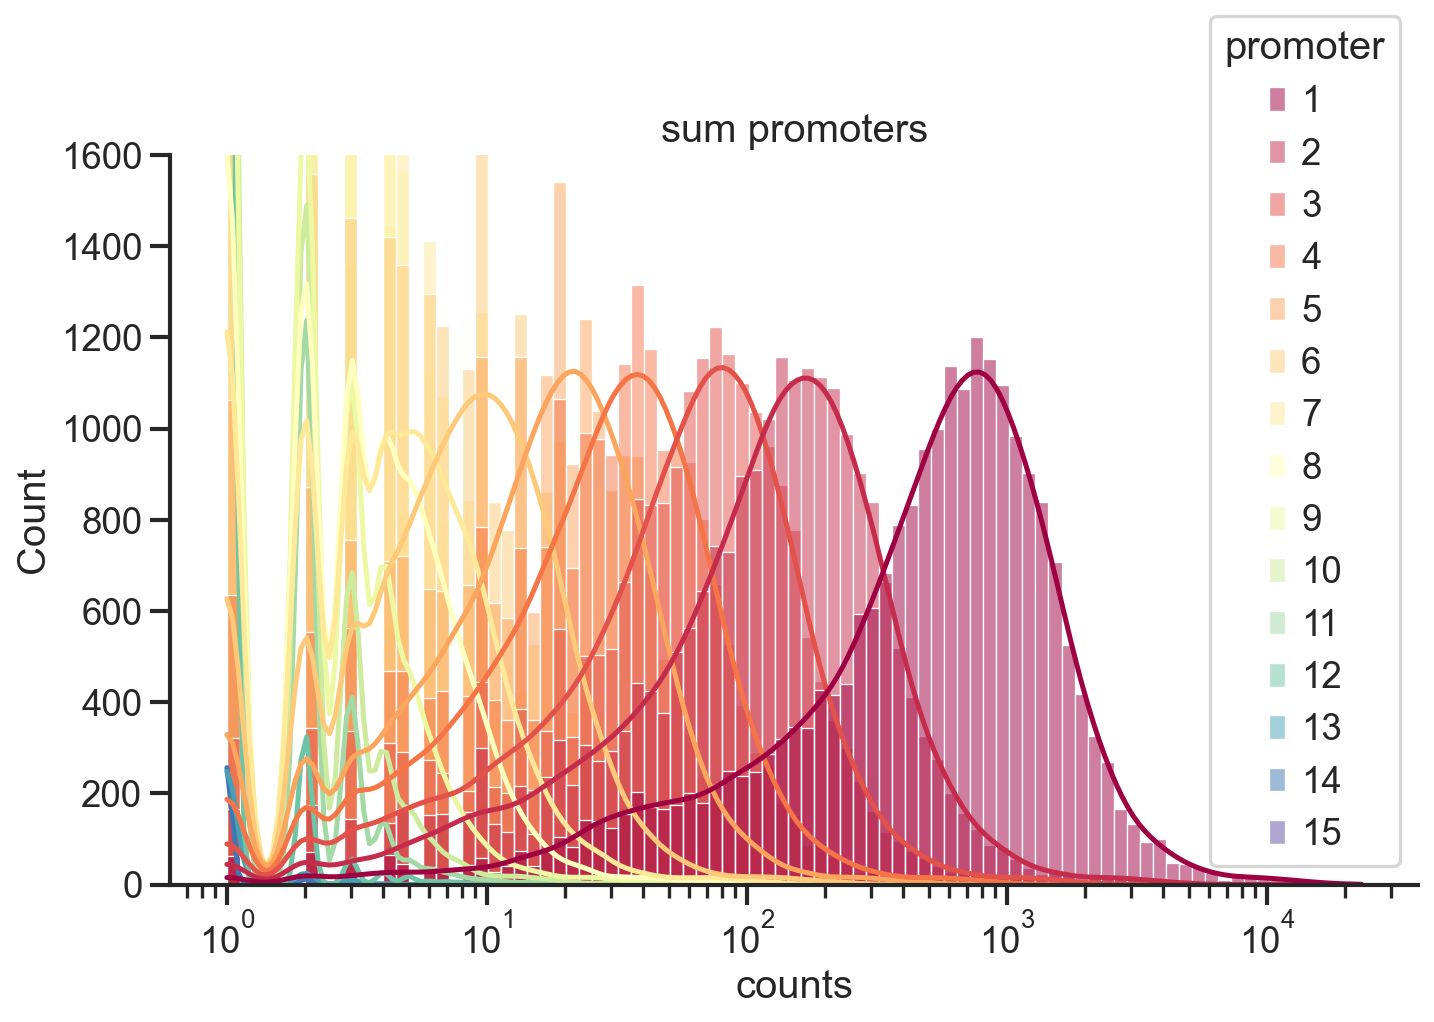

In [290]:
plt.figure(figsize=(10,6))
ax = sns.histplot(plot_prom, x = 'counts', kde = True, 
             log_scale = True,
                  hue = 'promoter', palette = 'Spectral',
             )
plt.title('sum promoters')

ax.set_ylim([0,1600])
sns.despine()
plt.show()

In [291]:
plot_prom

,promoter,cell,counts
0,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_1,11.0
1,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1021.0
2,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,954.0
3,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,544.0
4,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,1162.0
...,...,...,...
368635,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,4.0
368636,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1.0
368637,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,1.0
368638,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_383,8.0


In [292]:
plot_prom.index = plot_prom['cell']
plot_prom['hour'] = metadata['hour']
plot_prom['pseudo'] = metadata['pseudotime']
plot_prom['lineage'] = metadata['lineage']
plot_prom = plot_prom.reset_index(drop=True)

In [293]:
plot_prom['pseudo_round'] = plot_prom['pseudo'].round(0)
plot_prom_pseudo = plot_prom[~plot_prom['pseudo_round'].isna()]

In [294]:
plot_prom_pseudo['prom_simple'] = plot_prom_pseudo['promoter']
plot_prom_pseudo.loc[plot_prom_pseudo['prom_simple'] > 1, 'prom_simple'] = 'alt'

In [295]:
plot_prom_pseudo

,promoter,cell,counts,hour,pseudo,lineage,pseudo_round,prom_simple
1,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1021.0,72h,27.279612,Pluripotent,27.0,1
2,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,954.0,72h,27.501333,Pluripotent,28.0,1
3,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,544.0,72h,15.200164,Pluripotent,15.0,1
4,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,1162.0,72h,26.562374,Pluripotent,27.0,1
5,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_6,711.0,72h,26.777443,Pluripotent,27.0,1
...,...,...,...,...,...,...,...,...
213061,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_379,3.0,mESCs,1.366939,Pluripotent,1.0,alt
213062,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,4.0,mESCs,0.605807,Pluripotent,1.0,alt
213063,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1.0,mESCs,4.926665,Pluripotent,5.0,alt
213064,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,1.0,mESCs,0.662038,Pluripotent,1.0,alt


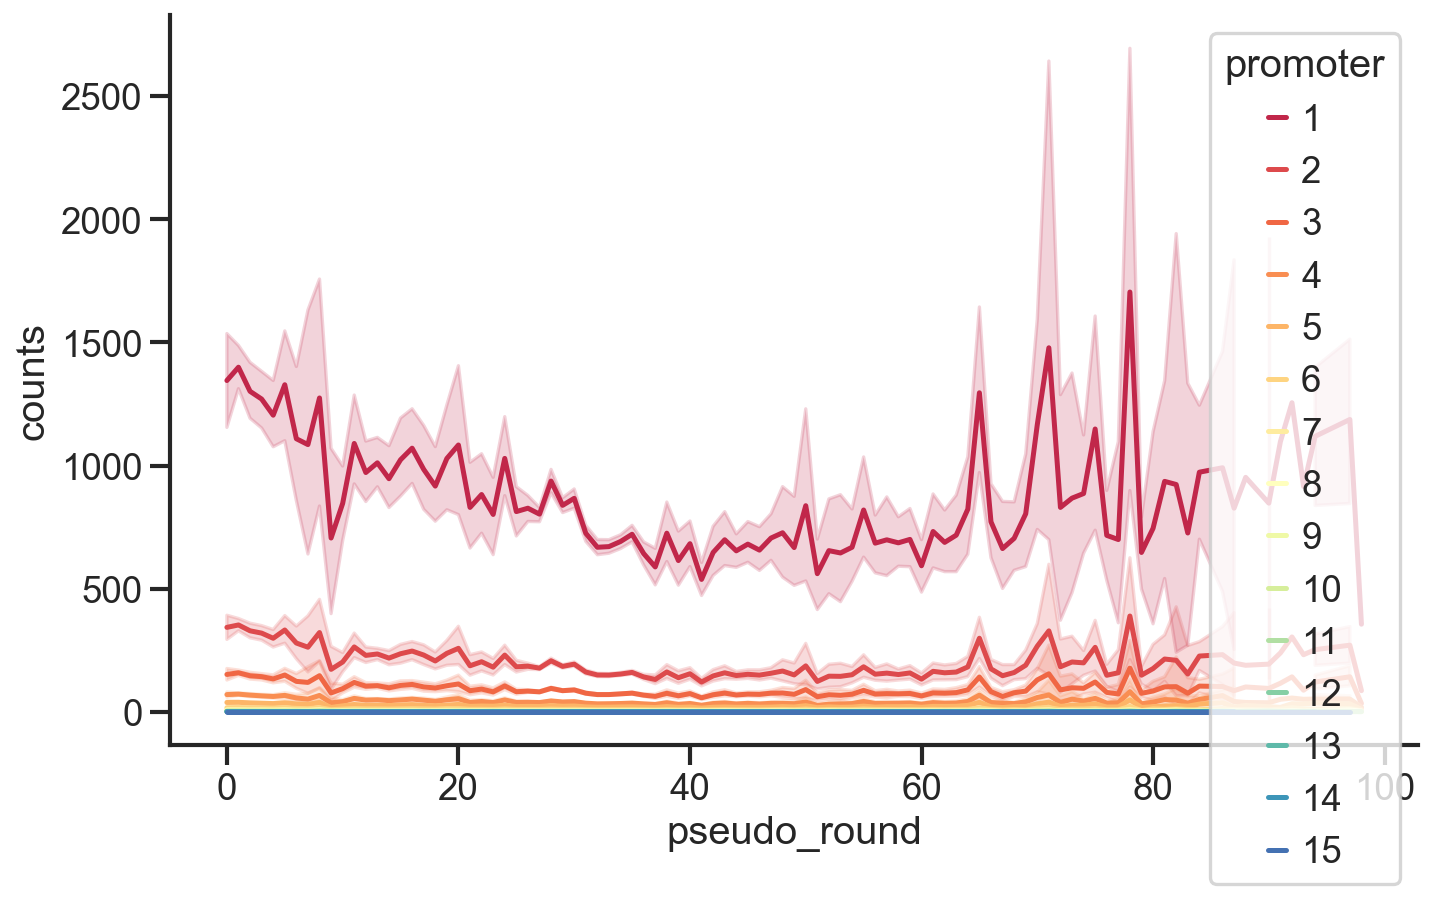

In [296]:
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo,
            x = 'pseudo_round',
            y = 'counts',
            palette = sns.color_palette('Spectral',15),
            hue = 'promoter')

#plt.title('sum promoters')

#ax.set_ylim([0,1600])
sns.despine()
plt.show()

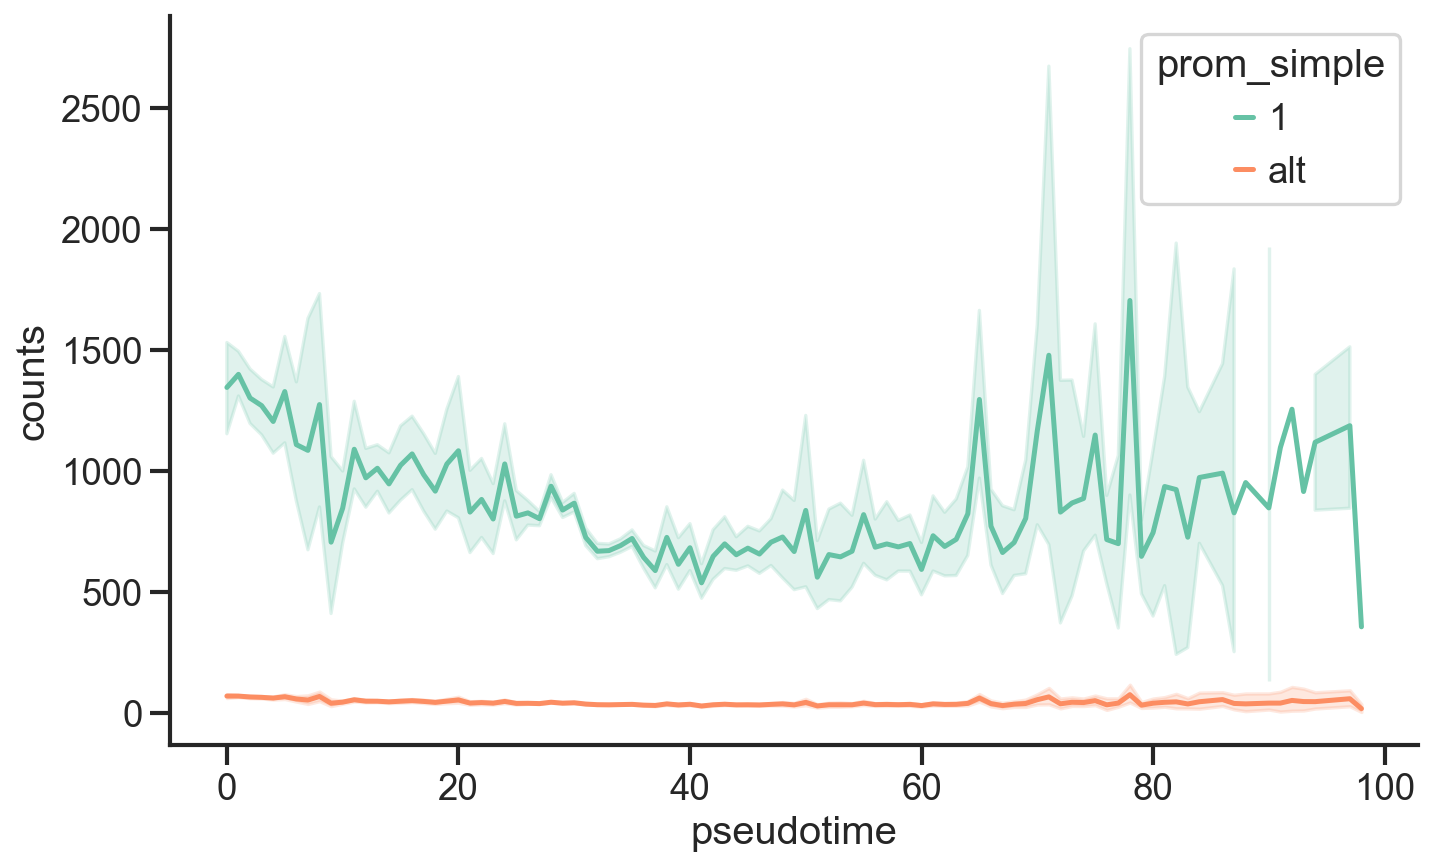

In [297]:
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo,
            x = 'pseudo_round',
            y = 'counts',
            palette = 'Set2',
            hue = 'prom_simple')

#plt.title('sum promoters')
plt.xlabel('pseudotime')
#ax.set_ylim([0,1600])
sns.despine()
plt.show()




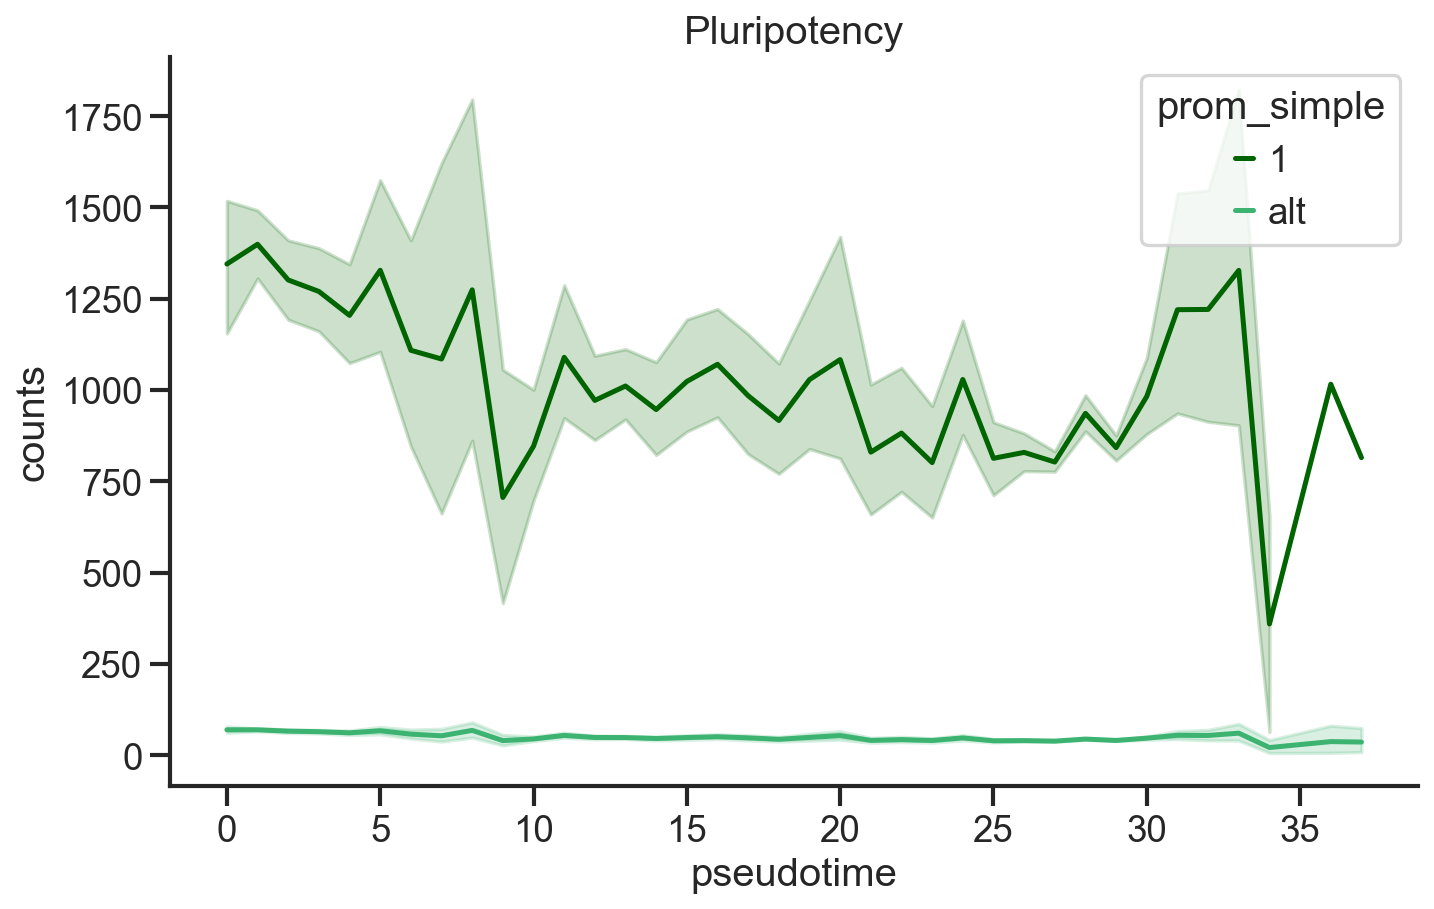

In [298]:
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'] == 'Pluripotent'],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['darkgreen','mediumseagreen'],
            hue = 'prom_simple')

plt.title('Pluripotency')
plt.xlabel('pseudotime')
#ax.set_ylim([0,1600])
sns.despine()
plt.show()




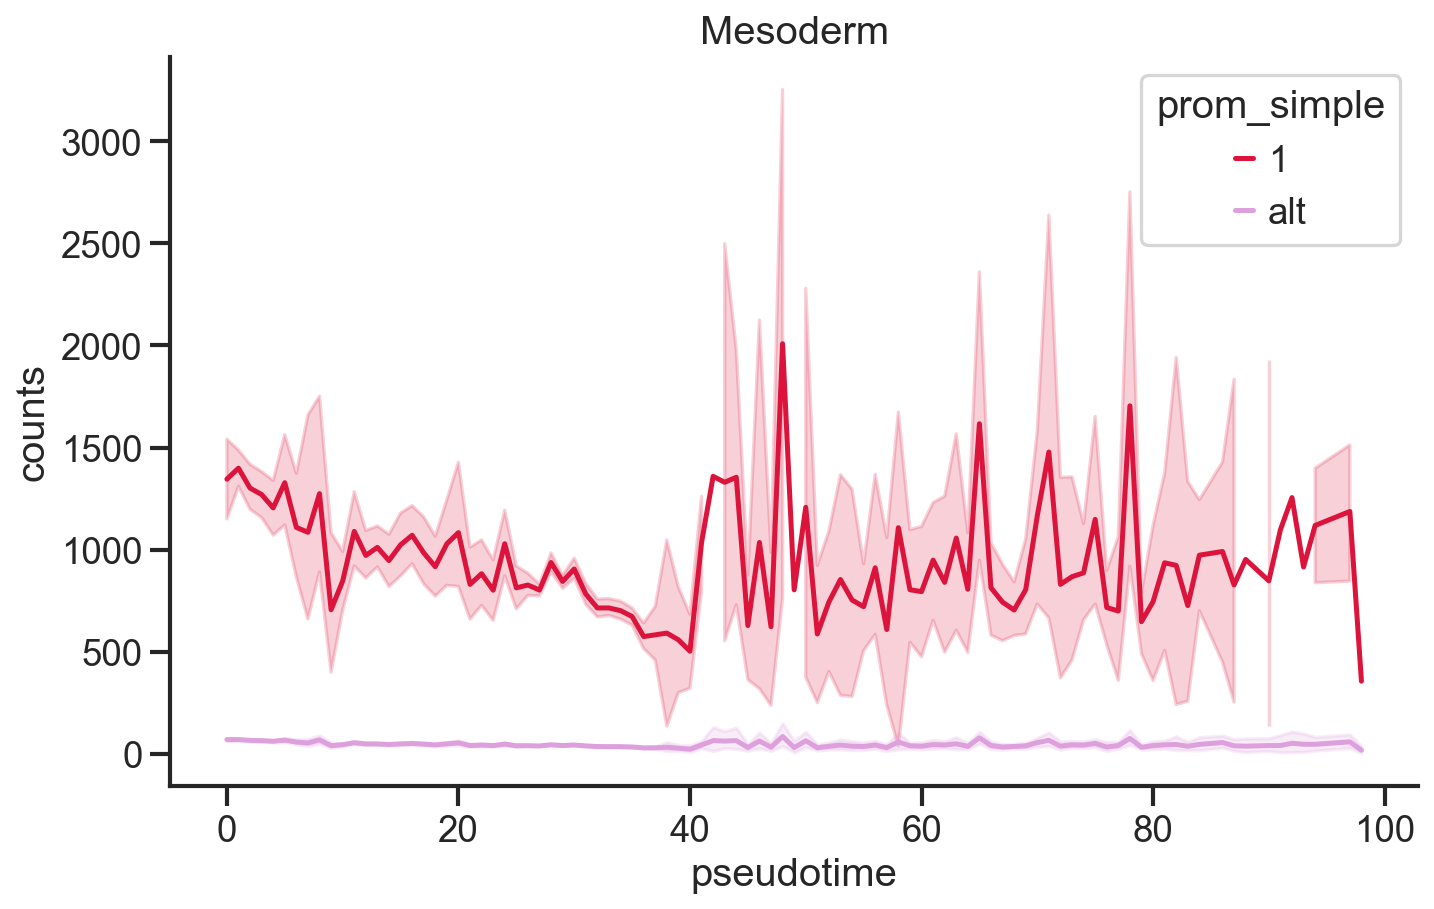

In [299]:
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Mesoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['crimson','plum'],
            hue = 'prom_simple')

plt.title('Mesoderm')
plt.xlabel('pseudotime')
#ax.set_ylim([0,1600])
sns.despine()
plt.show()




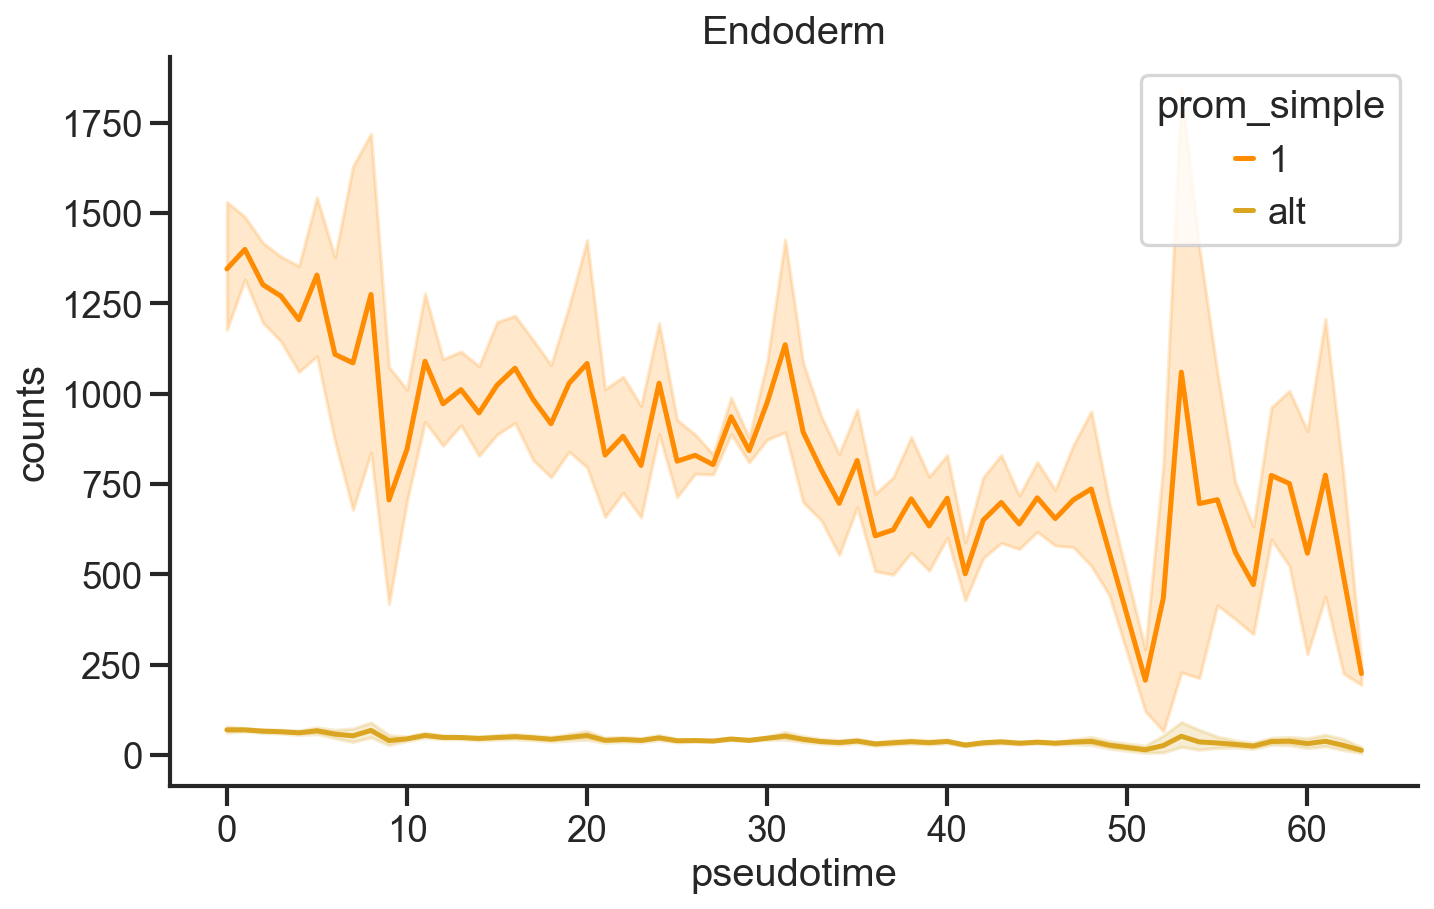

In [300]:
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Endoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['darkorange','goldenrod'],
            hue = 'prom_simple')

plt.title('Endoderm')
plt.xlabel('pseudotime')
#ax.set_ylim([0,1600])
sns.despine()
plt.show()




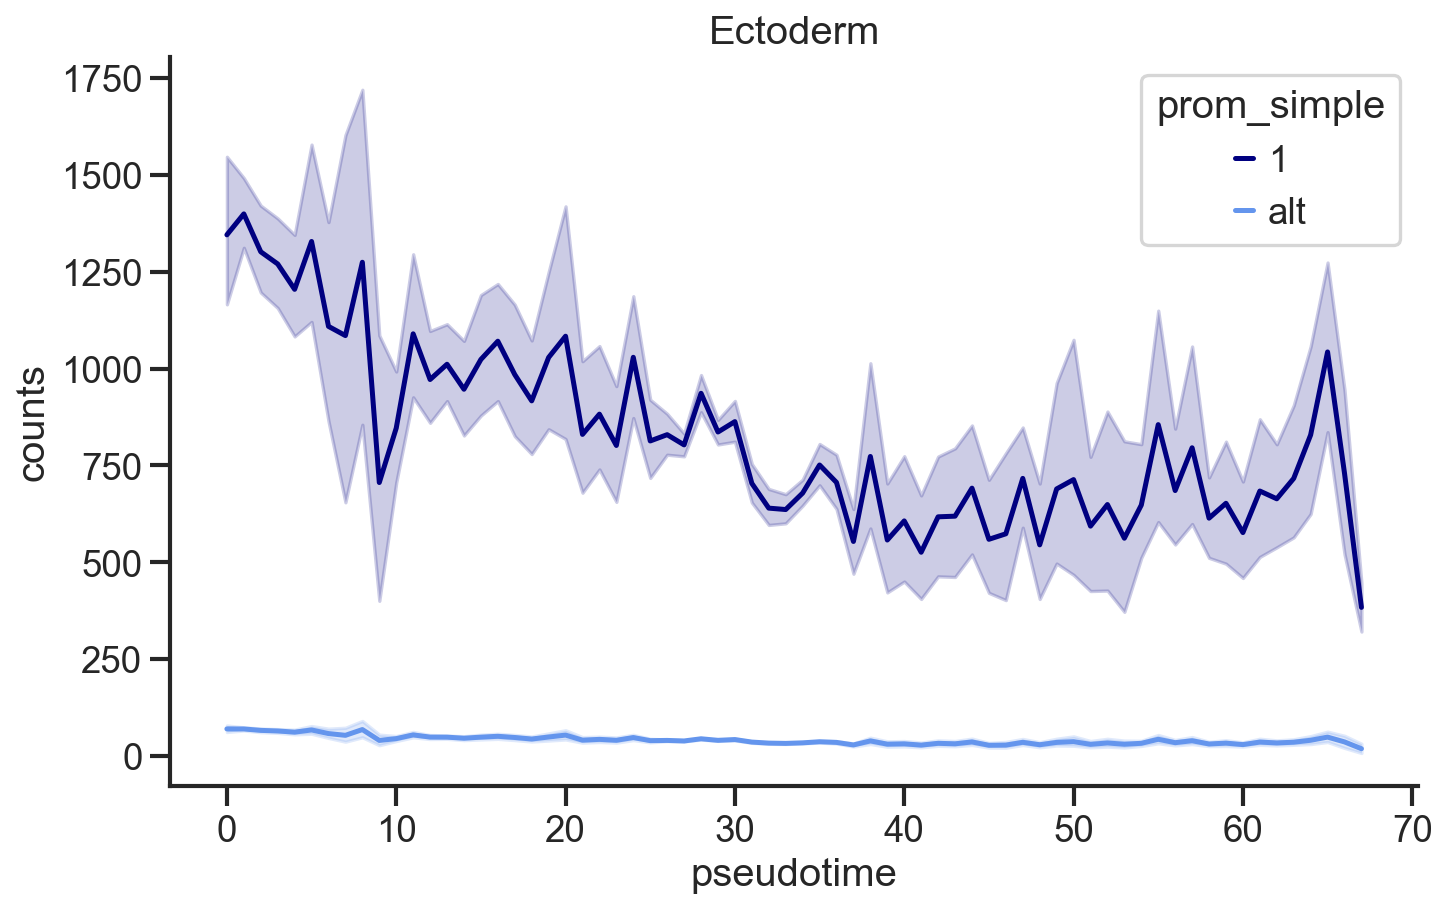

In [301]:
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Ectoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['navy','cornflowerblue'],
            hue = 'prom_simple')

plt.title('Ectoderm')
plt.xlabel('pseudotime')
#ax.set_ylim([0,1600])
sns.despine()
plt.show()




In [310]:
plot_prom_pseudo['hour'] = plot_prom_pseudo['hour'].astype('category').cat.reorder_categories(['mESCs','72h', '96h','120h', '144h', '168h' ])


,promoter,cell,counts,hour,pseudo,lineage,pseudo_round,prom_simple
1,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1021.0,72h,27.279612,Pluripotent,27.0,1
2,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,954.0,72h,27.501333,Pluripotent,28.0,1
3,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,544.0,72h,15.200164,Pluripotent,15.0,1
4,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,1162.0,72h,26.562374,Pluripotent,27.0,1
5,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_6,711.0,72h,26.777443,Pluripotent,27.0,1
...,...,...,...,...,...,...,...,...
213061,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_379,3.0,mESCs,1.366939,Pluripotent,1.0,alt
213062,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,4.0,mESCs,0.605807,Pluripotent,1.0,alt
213063,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1.0,mESCs,4.926665,Pluripotent,5.0,alt
213064,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,1.0,mESCs,0.662038,Pluripotent,1.0,alt


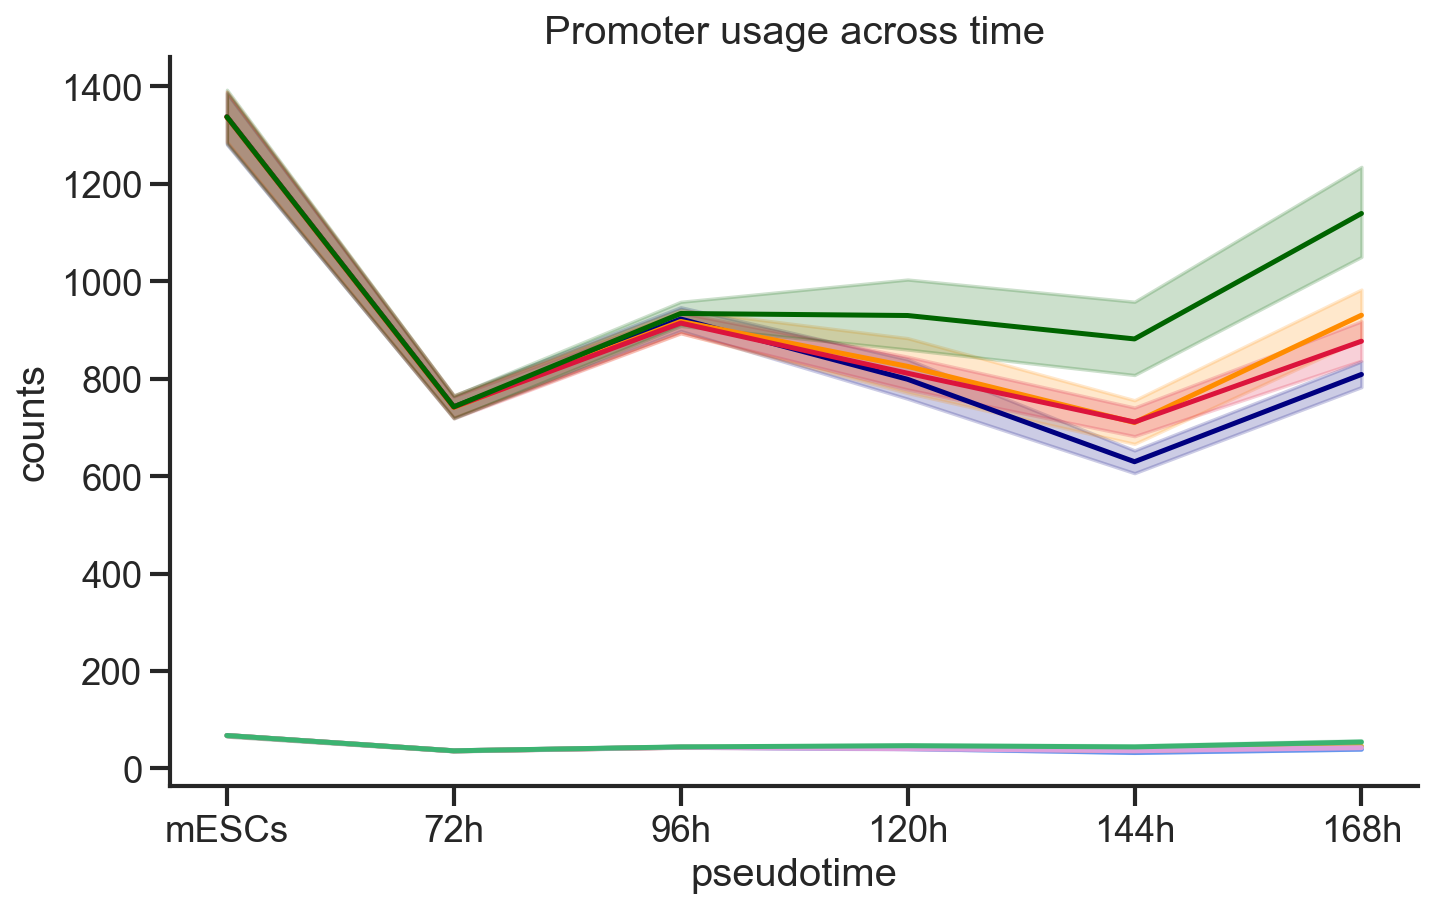

In [322]:
#fig, ax = plt.subplots(3,1, figsize=(10,6))
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Ectoderm'])],
            x = 'hour',
            y = 'counts',
            palette = ['navy','cornflowerblue'],
            hue = 'prom_simple')

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Endoderm'])],
            x = 'hour',
            y = 'counts',
            palette = ['darkorange','goldenrod'],
            hue = 'prom_simple')


sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Mesoderm'])],
            x = 'hour',
            y = 'counts',
            palette = ['crimson','plum'],
            hue = 'prom_simple')

sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent'])],
            x = 'hour',
            y = 'counts',
            palette = ['darkgreen','mediumseagreen'],
            hue = 'prom_simple')

plt.title('Promoter usage across time')
plt.xlabel('pseudotime')
plt.legend([],frameon=False)
#ax.set_ylim([0,1600])
sns.despine()
plt.show()





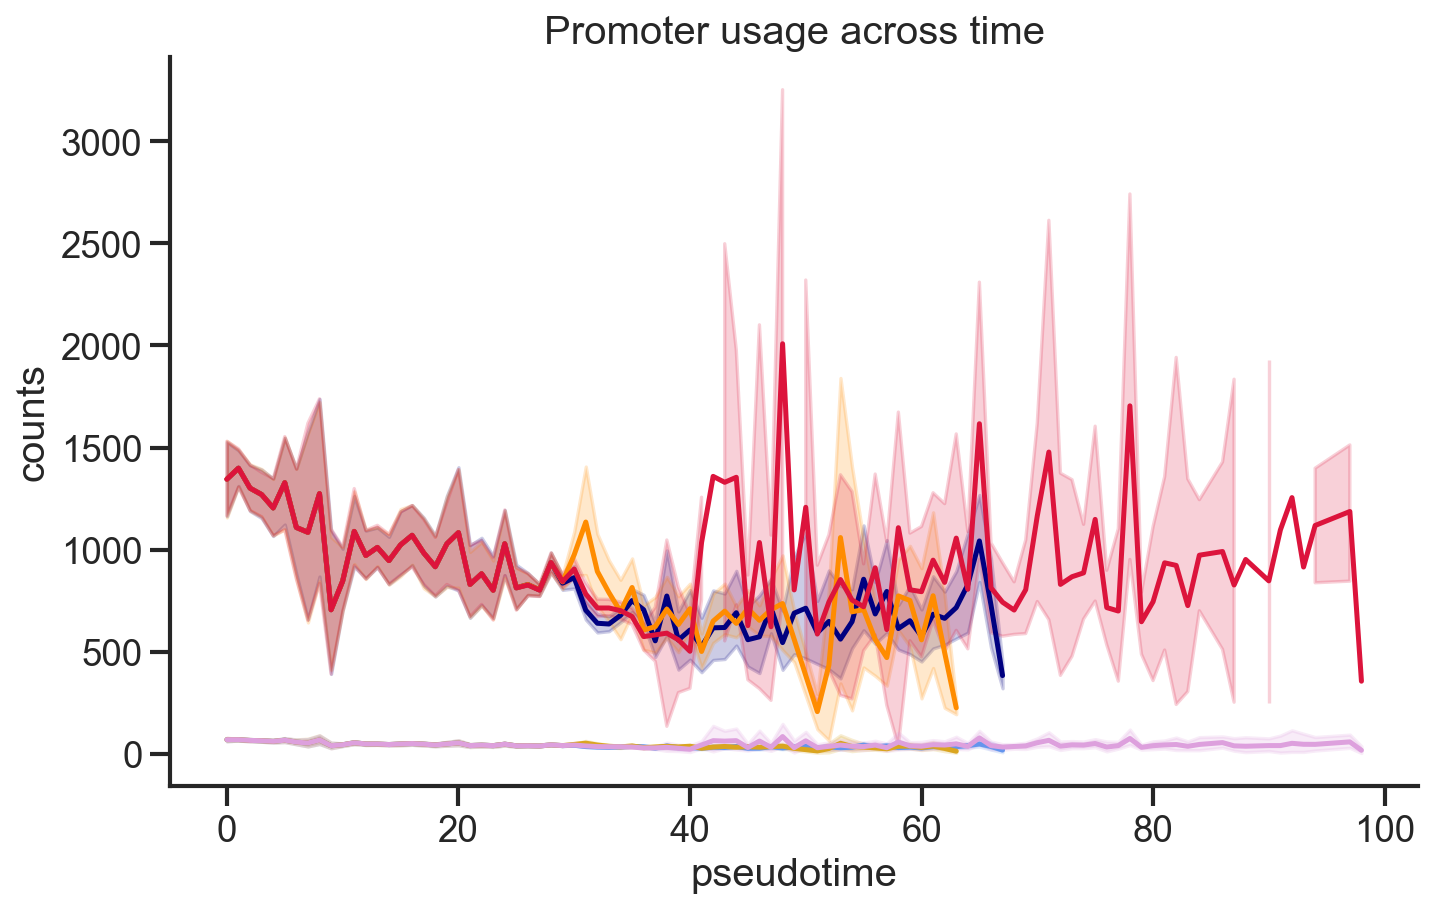

In [319]:
#fig, ax = plt.subplots(3,1, figsize=(10,6))
plt.figure(figsize=(10,6))


ax[0] = sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Ectoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['navy','cornflowerblue'],
            hue = 'prom_simple')

ax[0].set_title('Ectoderm')
ax[0].set_xlabel('pseudotime')
#ax.set_ylim([0,1600])
#sns.despine()
#plt.show()

ax[1] = sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Endoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['darkorange','goldenrod'],
            hue = 'prom_simple')

ax[1].set_title('Endoderm')
ax[1].set_xlabel('pseudotime')
#ax.set_ylim([0,1600])
#sns.despine()
#plt.show()


ax[2] = sns.lineplot(data = plot_prom_pseudo[plot_prom_pseudo['lineage'].isin( ['Pluripotent','Mesoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['crimson','plum'],
            hue = 'prom_simple')

ax[2].set_title('Promoter usage across time')
ax[2].set_xlabel('pseudotime')
plt.legend([],frameon=False)
#ax.set_ylim([0,1600])
sns.despine()
plt.show()





In [332]:
plot_prom_pseudo

,promoter,cell,counts,hour,pseudo,lineage,pseudo_round,prom_simple
1,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,1021.0,72h,27.279612,Pluripotent,27.0,1
2,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,954.0,72h,27.501333,Pluripotent,28.0,1
3,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,544.0,72h,15.200164,Pluripotent,15.0,1
4,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,1162.0,72h,26.562374,Pluripotent,27.0,1
5,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_6,711.0,72h,26.777443,Pluripotent,27.0,1
...,...,...,...,...,...,...,...,...
213061,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_379,3.0,mESCs,1.366939,Pluripotent,1.0,alt
213062,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,4.0,mESCs,0.605807,Pluripotent,1.0,alt
213063,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1.0,mESCs,4.926665,Pluripotent,5.0,alt
213064,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,1.0,mESCs,0.662038,Pluripotent,1.0,alt


In [343]:
plot_prom[['hour','promoter','counts']].groupby(['promoter','hour'], axis=0).sum().sort_values(by='hour').reset_index()

#.value_counts()).sort_values(by='hour').rename(columns={0:'counts'})

,promoter,hour,counts
0,1,120h,2591976.0
1,8,120h,10816.0
2,9,120h,5996.0
3,6,120h,30827.0
4,10,120h,3164.0
...,...,...,...
85,12,mESCs,741.0
86,10,mESCs,3941.0
87,6,mESCs,31492.0
88,5,mESCs,71938.0


In [344]:
counts = plot_prom[['hour','promoter','counts']].groupby(['promoter','hour'], axis=0).sum().sort_values(by='hour').reset_index()


countsf_reformat = counts.pivot(index='hour', columns='promoter', values='counts')#.reset_index()
countsf_reformat = countsf_reformat.fillna(0)
countsf_reformat = countsf_reformat.reset_index()
countsf_reformat = countsf_reformat.iloc[[5,3,4,0,1,2],:]
countsf_reformat

promoter,hour,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
5,mESCs,2614021.0,659325.0,294907.0,134524.0,71938.0,31492.0,15582.0,11144.0,6315.0,3941.0,2030.0,741.0,137.0,106.0,172.0
3,72h,1481627.0,331822.0,150112.0,69440.0,39632.0,17316.0,8351.0,5940.0,3433.0,1803.0,1099.0,483.0,16.0,12.0,124.0
4,96h,3374380.0,746604.0,345693.0,160409.0,90658.0,39042.0,19267.0,13369.0,7721.0,4060.0,2529.0,982.0,52.0,10.0,282.0
0,120h,2591976.0,586389.0,271440.0,126291.0,71253.0,30827.0,15059.0,10816.0,5996.0,3164.0,2138.0,826.0,33.0,19.0,249.0
1,144h,2164186.0,489206.0,228737.0,106154.0,60640.0,26370.0,12919.0,9273.0,5070.0,2733.0,1853.0,633.0,42.0,14.0,195.0
2,168h,2949679.0,657750.0,311363.0,145534.0,84393.0,37339.0,18091.0,12482.0,6926.0,3709.0,2675.0,913.0,44.0,16.0,250.0


In [345]:
pd.Categorical(counts['promoter']).categories

Int64Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], dtype='int64')

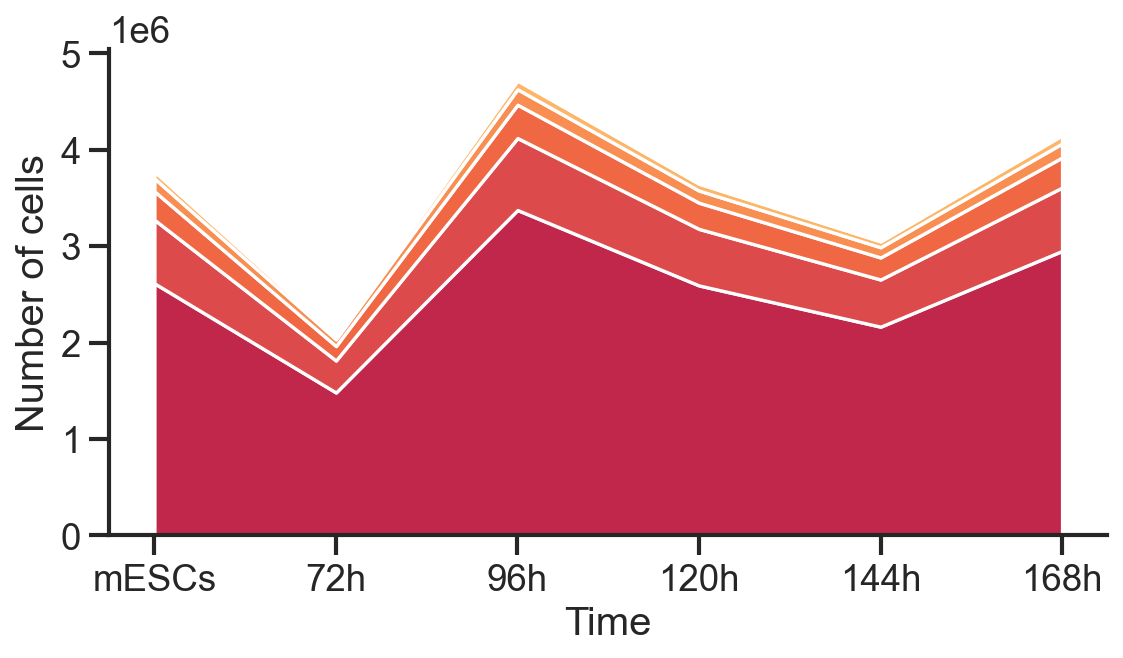

In [346]:
color_map = list(sns.color_palette('Spectral', 15)) #list(adata.uns['celltype_colors'])

fig,ax = plt.subplots(figsize=(8,4))

list_celltypes = list(pd.Categorical(counts['promoter']).categories)

plt.stackplot(countsf_reformat.hour, 
              [countsf_reformat[x] for x in list_celltypes],
              labels=list_celltypes,
             colors = color_map)
sns.despine()

#add legend
#plt.legend(loc='upper left')

#add axis labels
plt.xlabel('Time')
plt.ylabel('Number of cells')

#display area chart
plt.show()

In [347]:
countsf_perc = counts.pivot(index='hour', columns='promoter', values='counts')#.reset_index()
countsf_perc = countsf_perc.fillna(0)
for tp in countsf_perc.index:
    countsf_perc.loc[tp] = countsf_perc.loc[tp]/sum(countsf_perc.loc[tp])*100

countsf_perc = countsf_perc.reset_index()

#color_map = list(sns.color_palette('Spectral', 15)) #list(adata.uns['celltype_colors'])
#list_celltypes = list(pd.Categorical(metadata['celltype']).categories)

res = {list_celltypes[i]: color_map[i] for i in range(len(list_celltypes))}

#key_order = ['mESCs', 'Primitive Streak', 'Caudal Epiblast', 'Epiblast', 'Naive PGCs', 'Epidermis Progenitors', 'PGCs','Reprogramming PGCs','Caudal Mesoderm',
#             'preSomitic/Wavefront', 'Nascent Mesoderm','LP/Intermediate Mesoderm','Somite', 'Cardiac Mesoderm','Dermomyotome','Sclerotome',
#              'Cardiomyocytes', 'Pharyngeal Mesoderm','Myotome','NMPs','Neural Progenitors','Roof Plate Neural Tube','Floor Plate Neural Tube',
#              'Early Motor Neurons','Late Motor Neurons','Parietal Endoderm','Visceral Endoderm','ExE Endoderm','Endothelium','Erythrocytes','Megakaryocytes']

#new_order = collections.OrderedDict((k, res[k]) for k in key_order)

In [348]:
countsf_perc = countsf_perc.iloc[[5,3,4,0,1,2],:]

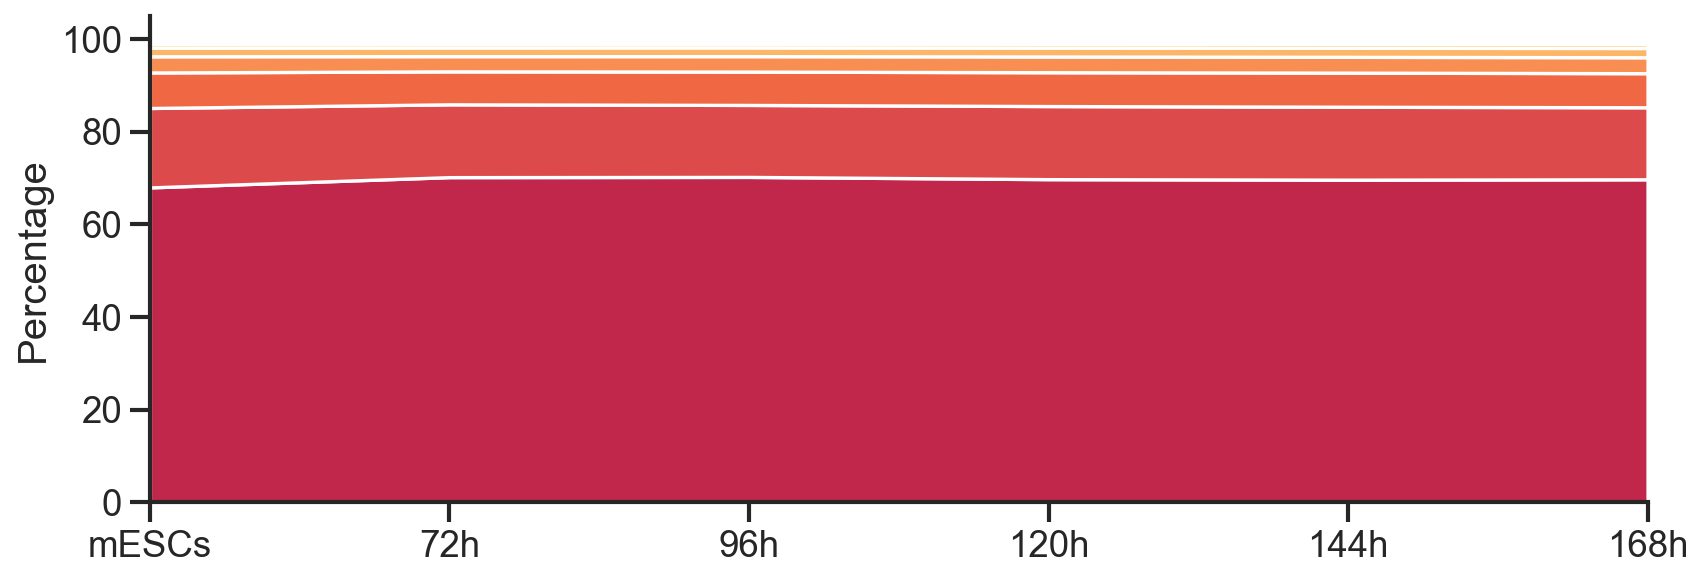

In [349]:
sns.set_style('white')
sns.set_style('ticks')
sns.set_context('talk')

#list_celltypes = new_order.keys()
#color_map = new_order.values()

fig,ax = plt.subplots(figsize=(12,4))


plt.stackplot(countsf_perc.hour, 
              [countsf_perc[x] for x in list_celltypes],
              labels=list_celltypes,
             colors = color_map)
sns.despine()

#add legend
#plt.legend(loc='upper left')

#add axis labels
plt.xlabel('')
plt.ylabel('Percentage')
plt.margins(x=0)
#display area chart
plt.show()

In [357]:
count_TSS = pd.DataFrame(k4_binary.sum(axis=0)).rename(columns={0:'counts'}).reset_index()



In [365]:
count_TSS[count_TSS['promoter'] != '1'].sort_values(by = 'counts',ascending=False)

,gene,promoter,counts
60535,Malat1,2,6577.0
60526,Fam192a,3,5338.0
60524,Srgap2,9,5145.0
60517,Epha4,2,5018.0
60522,Kdm2b,9,5010.0
...,...,...,...
140,Raet1e,3,13.0
115,Mthfs,3,13.0
4,Drr1,2,11.0
101,Pfkfb1,3,11.0


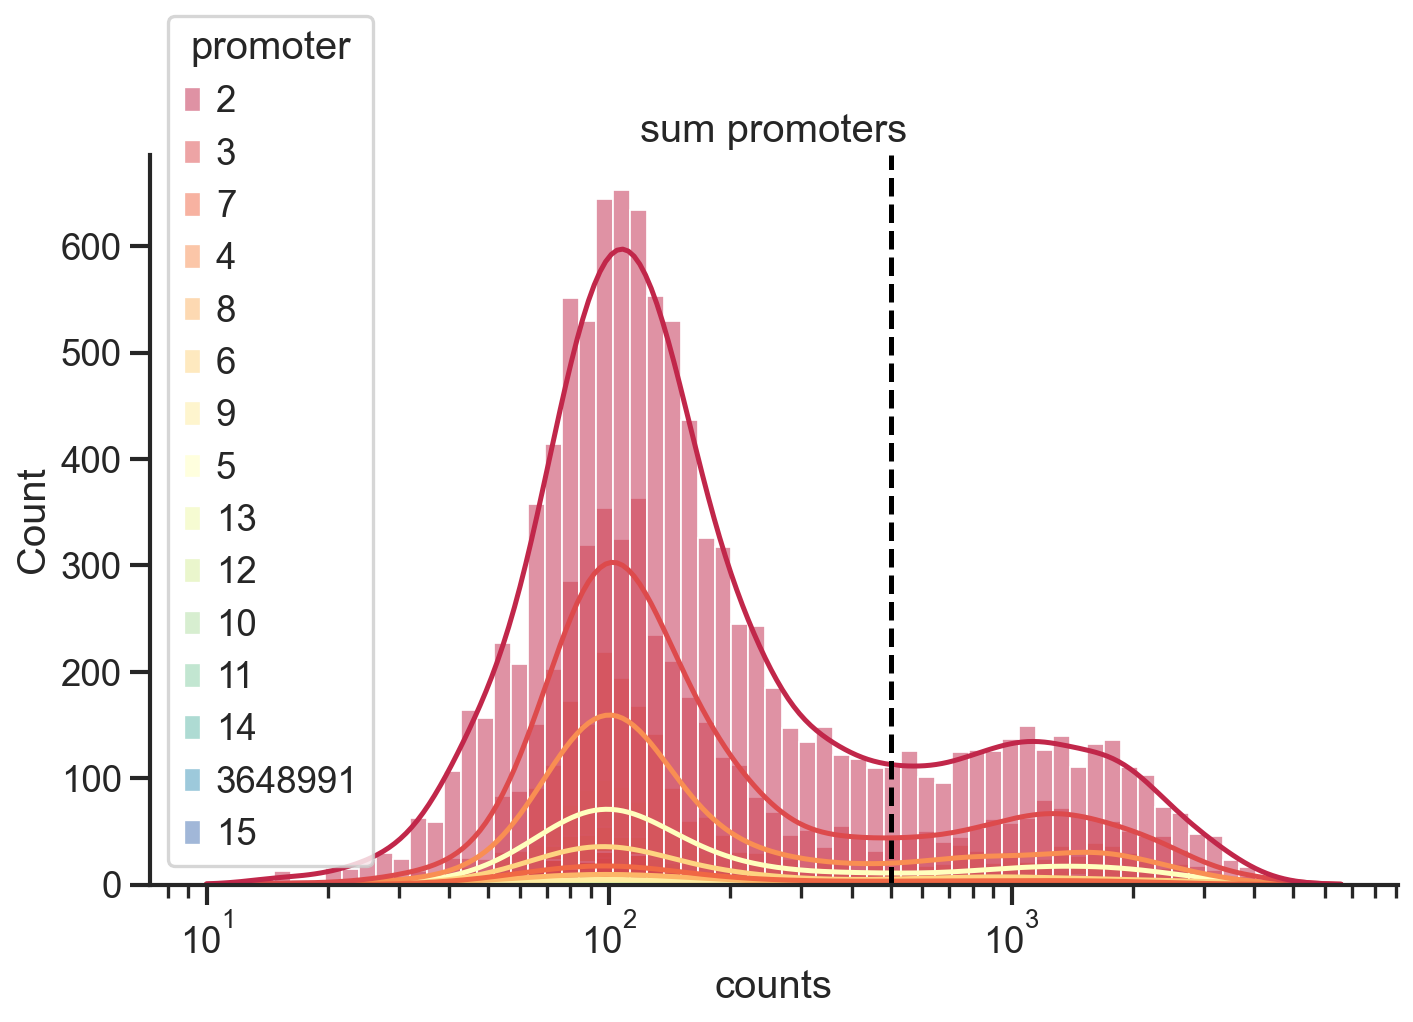

In [371]:
plt.figure(figsize=(10,6))
sns.histplot(count_TSS[count_TSS['promoter'] != '1'],
             x = 'counts', kde = True, 
             log_scale = True,
                  hue = 'promoter', palette = 'Spectral',
             )


plt.title('sum promoters')
plt.axvline(500, color = 'black', linestyle = '--')
ax.set_ylim([0,1600])
sns.despine()
plt.show()

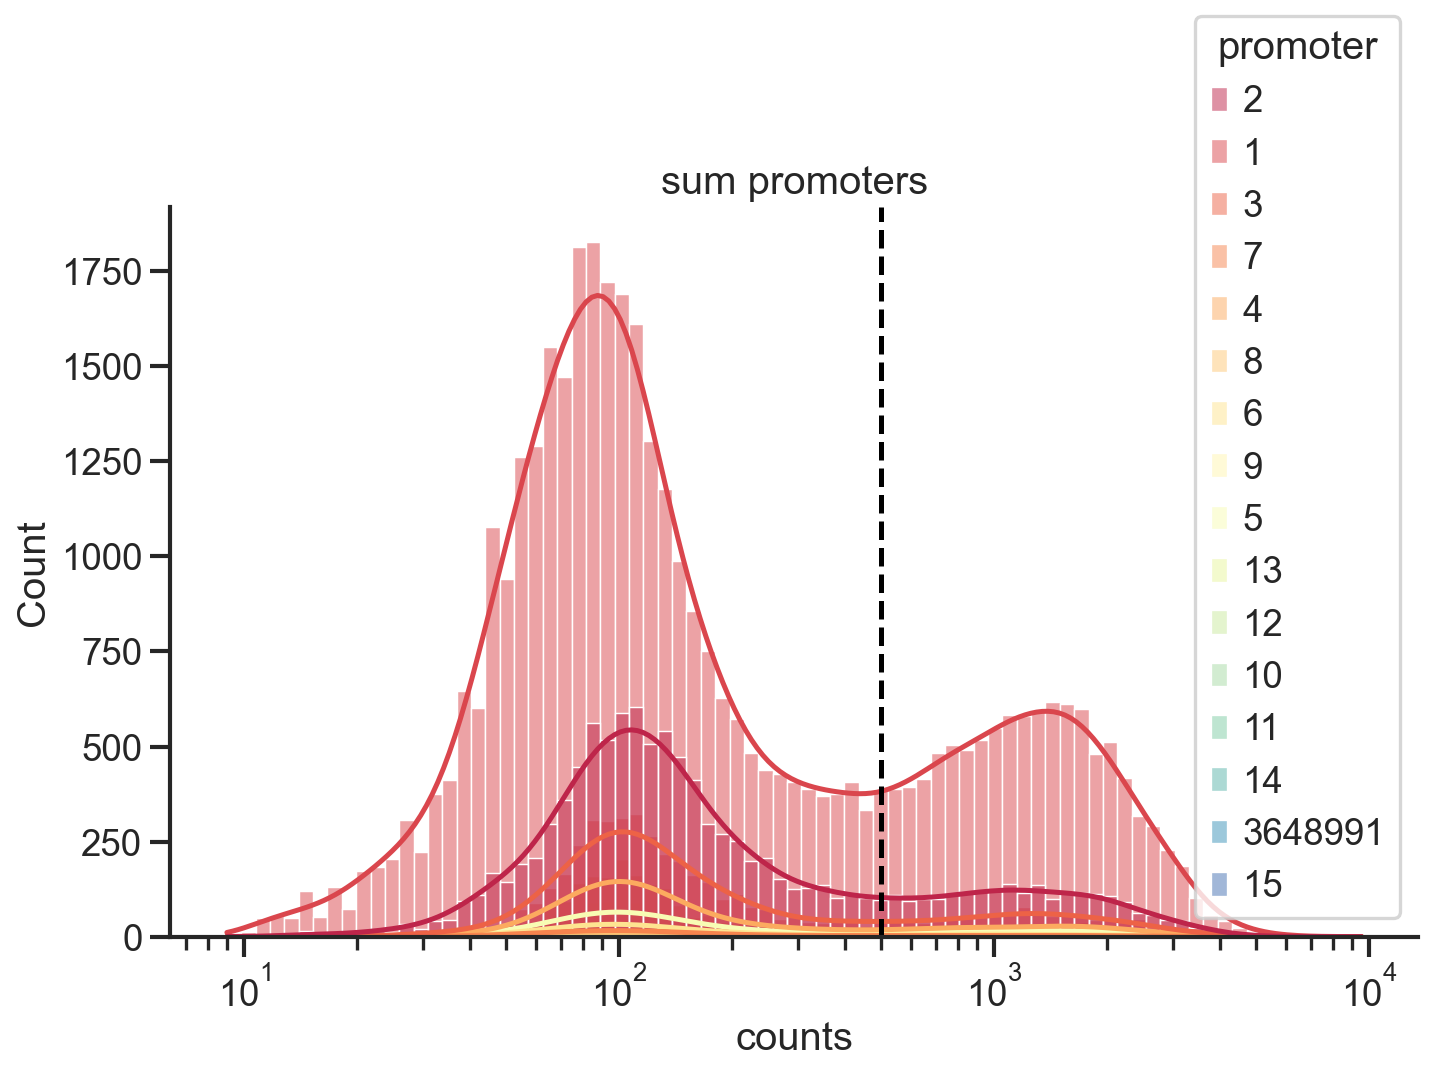

In [378]:
plt.figure(figsize=(10,6))

sns.histplot(count_TSS[count_TSS['counts'] != 0],
             x = 'counts', kde = True, 
             log_scale = True,
                  hue = 'promoter', palette = 'Spectral',
             )


plt.title('sum promoters')
plt.axvline(500, color = 'black', linestyle = '--')
ax.set_ylim([0,1600])
sns.despine()
plt.show()

In [384]:
count_alt_TSS = count_TSS[count_TSS['promoter'] != '1']
count_alt_TSS_high = count_alt_TSS[count_alt_TSS['counts'] > 500]

In [394]:
count_alt_TSS_high['gene'].unique()

array(['Magi2', 'Cd82', 'Wdr31', ..., 'Srgap2', 'Fam192a', 'Malat1'],
      dtype=object)

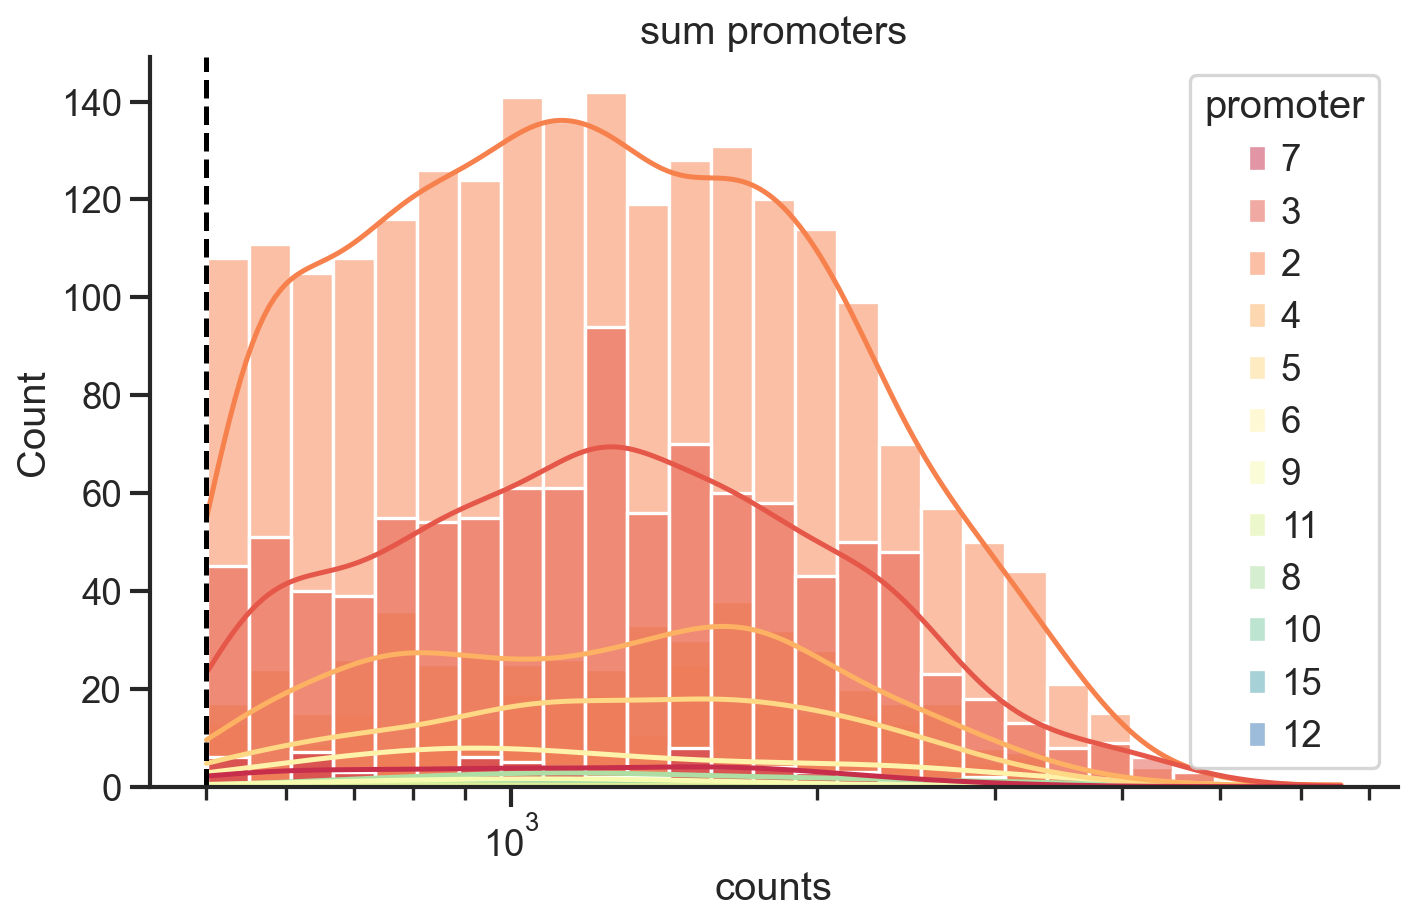

In [396]:
plt.figure(figsize=(10,6))

sns.histplot(count_alt_TSS_high,
             x = 'counts', kde = True, 
             log_scale = True,
                  hue = 'promoter', palette = 'Spectral',
             )


plt.title('sum promoters')
plt.axvline(500, color = 'black', linestyle = '--')
ax.set_ylim([0,1600])
sns.despine()
plt.show()

In [453]:
select = k4.columns.get_level_values(0).isin(list(count_alt_TSS_high['gene'].unique()))
k4_high = k4.loc[:, select]

In [454]:
k4_hbinary = np.sign(k4_high)
k4_hbinary.columns.names = ['gene','promoter']
k4_hprom = k4_hbinary.droplevel(0, axis = 1).groupby('promoter', axis=1).sum()
k4_hprom.index.names = ['cell']


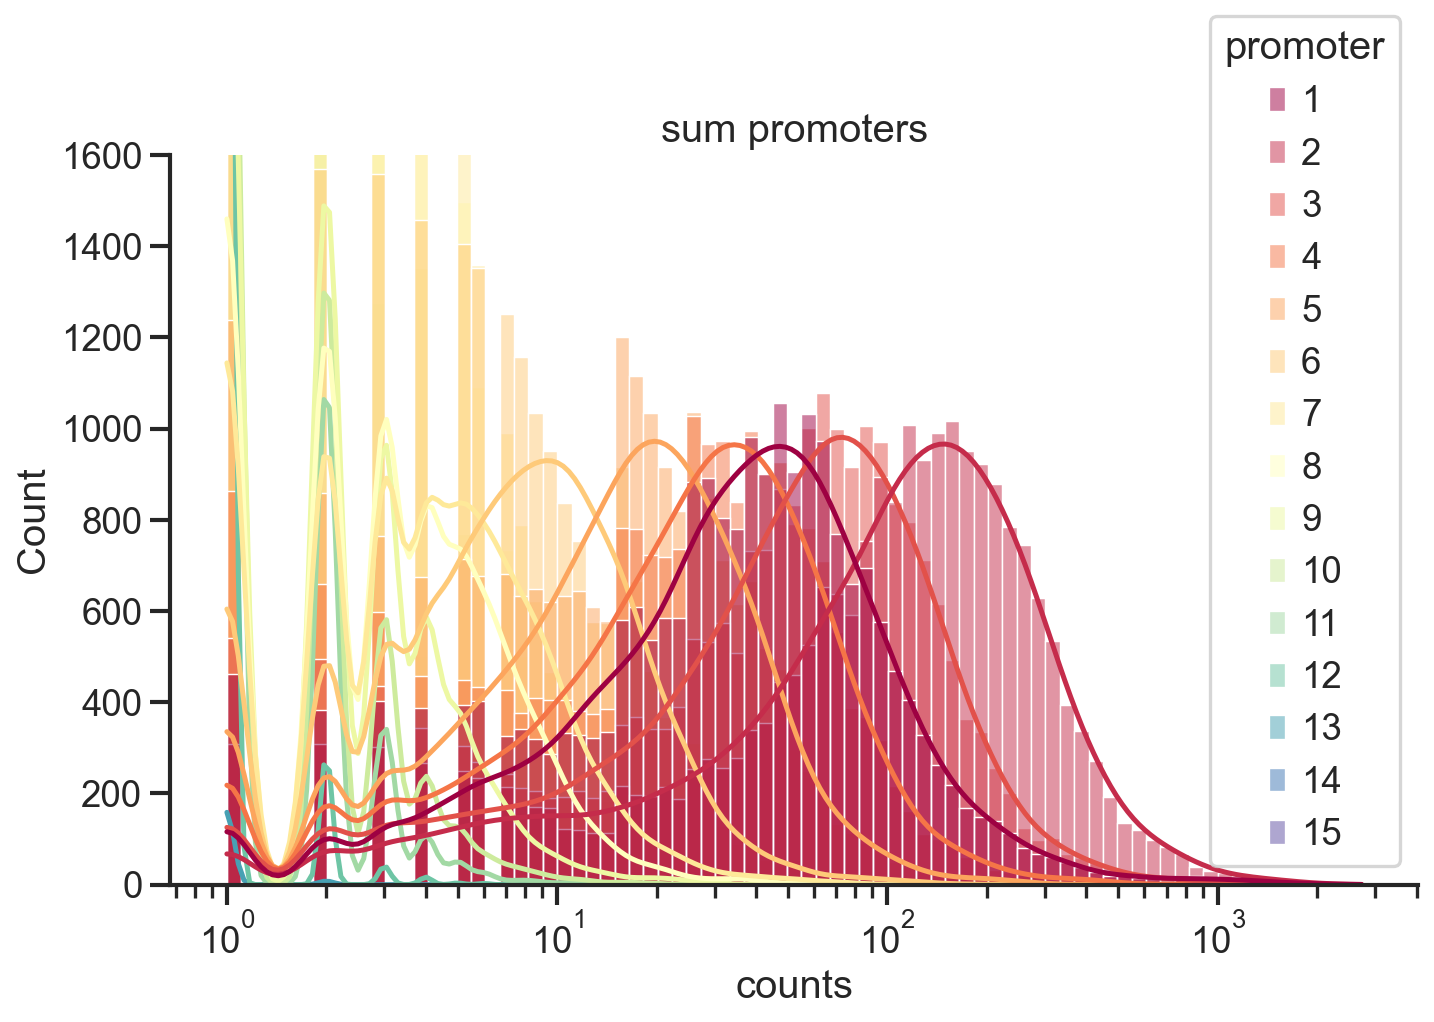

In [455]:
plot_hprom = pd.DataFrame(k4_hprom.unstack()).rename(columns={0:'counts'}).reset_index()

plot_hprom = plot_hprom[plot_hprom['counts'] != 0]
plot_hprom = plot_hprom[plot_hprom['counts'] != 0]
plot_hprom['promoter'] = plot_hprom['promoter'].astype(int)
plot_hprom = plot_hprom[plot_hprom['promoter'] < 20]

plt.figure(figsize=(10,6))
ax = sns.histplot(plot_hprom, x = 'counts', kde = True, 
             log_scale = True,
                  hue = 'promoter', palette = 'Spectral',
             )
plt.title('sum promoters')

ax.set_ylim([0,1600])
sns.despine()
plt.show()


In [456]:
plot_hprom.index = plot_hprom['cell']
plot_hprom['hour'] = metadata['hour']
plot_hprom['pseudo'] = metadata['pseudotime']
plot_hprom['lineage'] = metadata['lineage']
plot_hprom = plot_hprom.reset_index(drop=True)

plot_hprom['pseudo_round'] = plot_hprom['pseudo'].round(0)
plot_hprom_pseudo = plot_hprom[~plot_hprom['pseudo_round'].isna()]

plot_hprom_pseudo['prom_simple'] = plot_hprom_pseudo['promoter']
plot_hprom_pseudo.loc[plot_hprom_pseudo['prom_simple'] > 1, 'prom_simple'] = 'alt'

In [460]:
plot_hprom_pseudo['hour'] = plot_hprom_pseudo['hour'].astype('category').cat.reorder_categories(['mESCs','72h', '96h','120h', '144h', '168h' ])


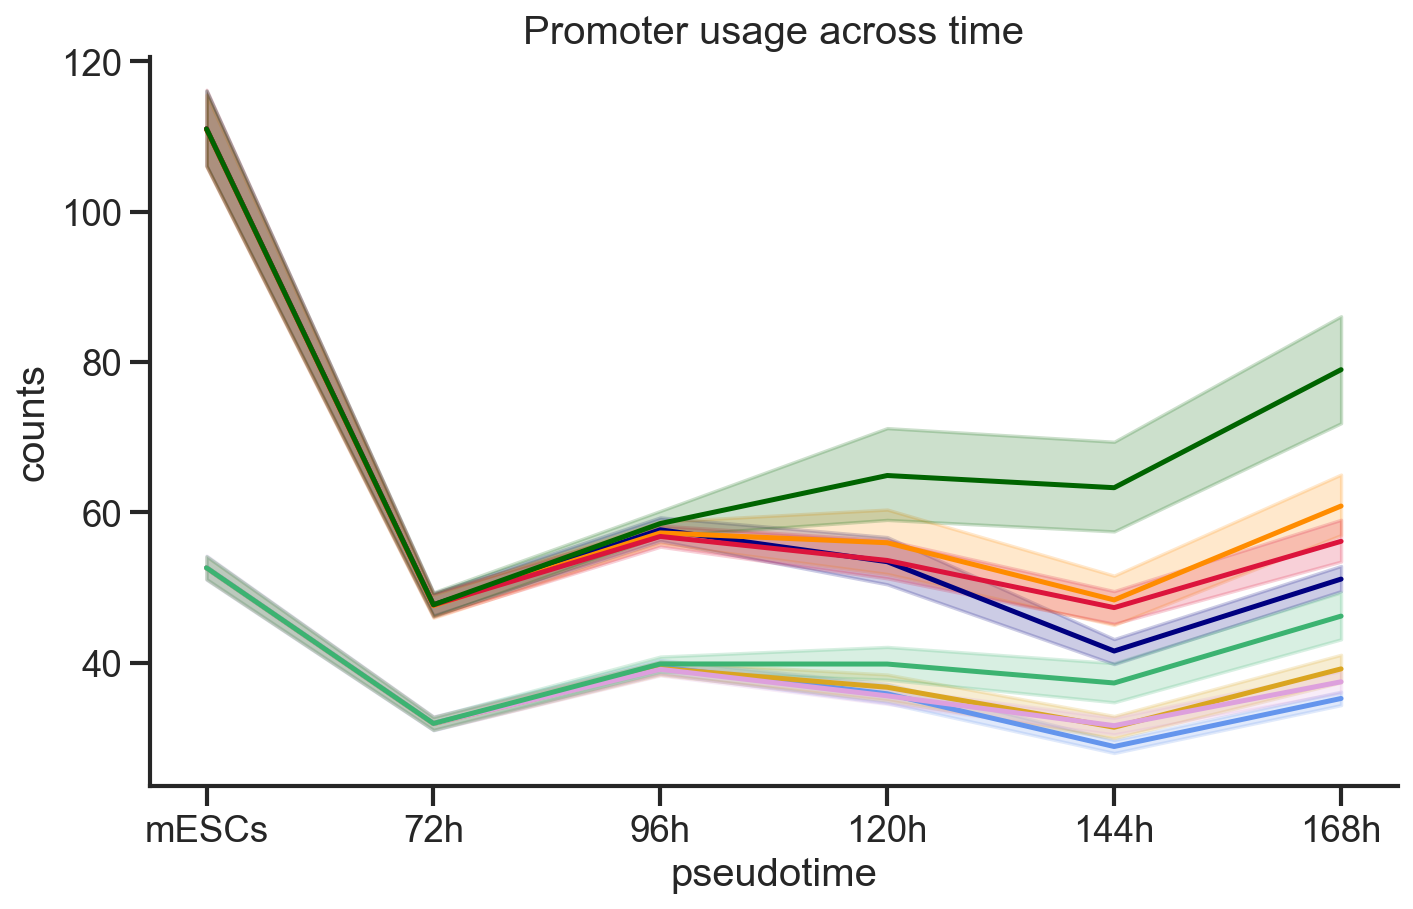

In [461]:
#fig, ax = plt.subplots(3,1, figsize=(10,6))
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent','Ectoderm'])],
            x = 'hour',
            y = 'counts',
            palette = ['navy','cornflowerblue'],
            hue = 'prom_simple')

sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent','Endoderm'])],
            x = 'hour',
            y = 'counts',
            palette = ['darkorange','goldenrod'],
            hue = 'prom_simple')


sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent','Mesoderm'])],
            x = 'hour',
            y = 'counts',
            palette = ['crimson','plum'],
            hue = 'prom_simple')

sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent'])],
            x = 'hour',
            y = 'counts',
            palette = ['darkgreen','mediumseagreen'],
            hue = 'prom_simple')

plt.title('Promoter usage across time')
plt.xlabel('pseudotime')
plt.legend([],frameon=False)
#ax.set_ylim([0,1600])
sns.despine()
plt.show()





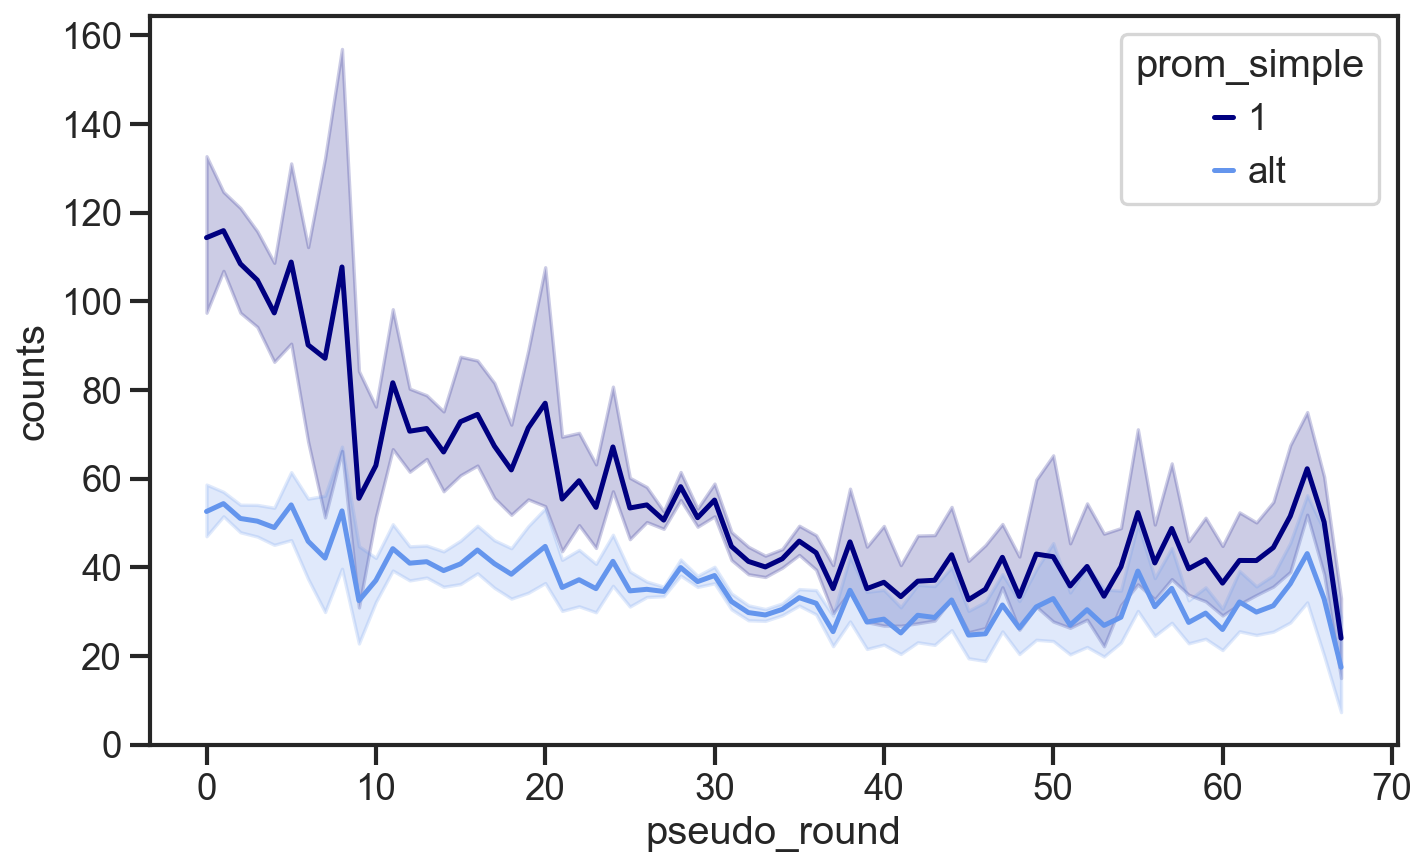

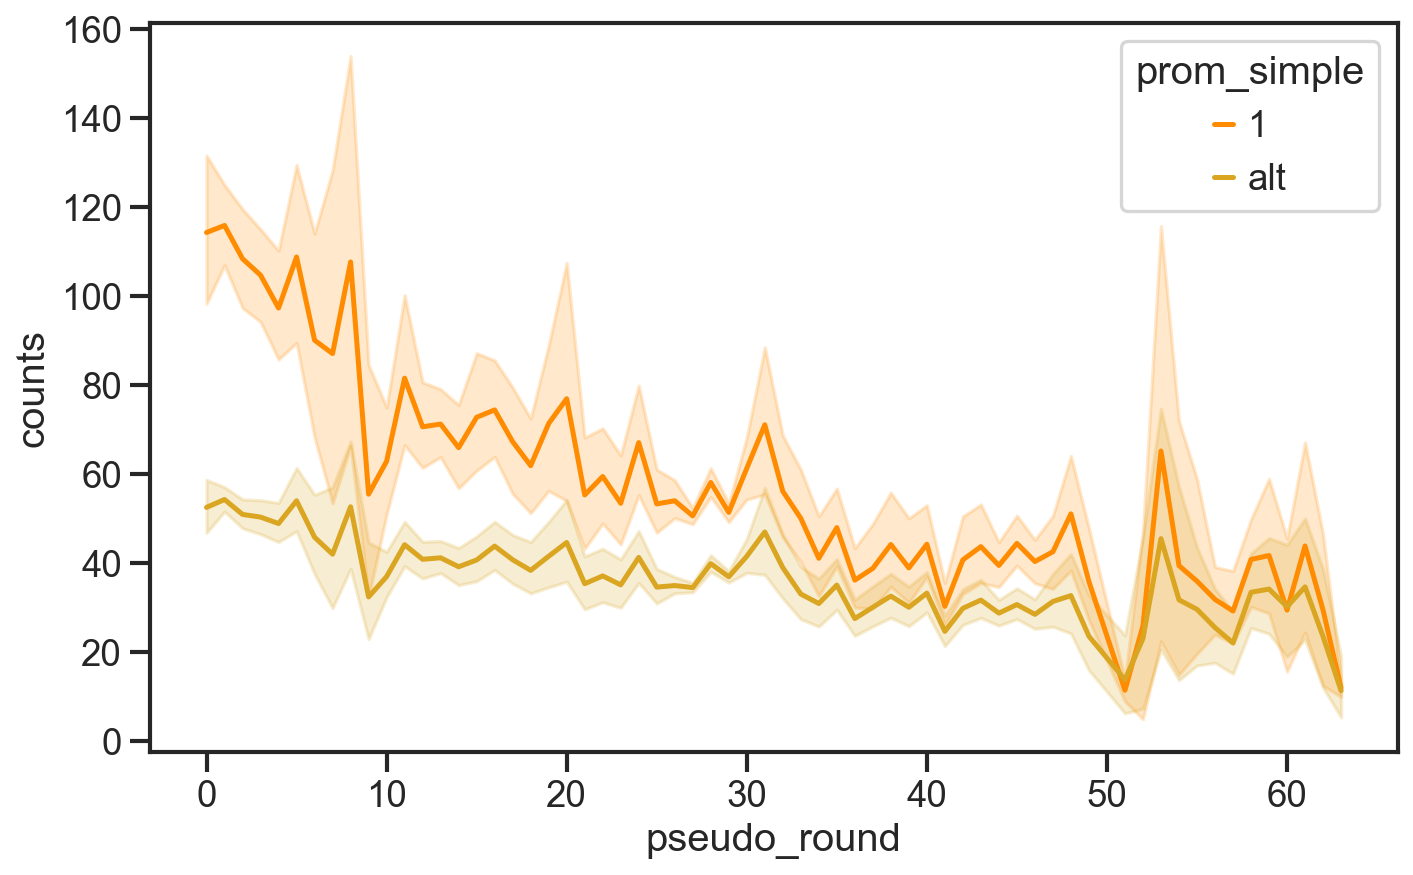

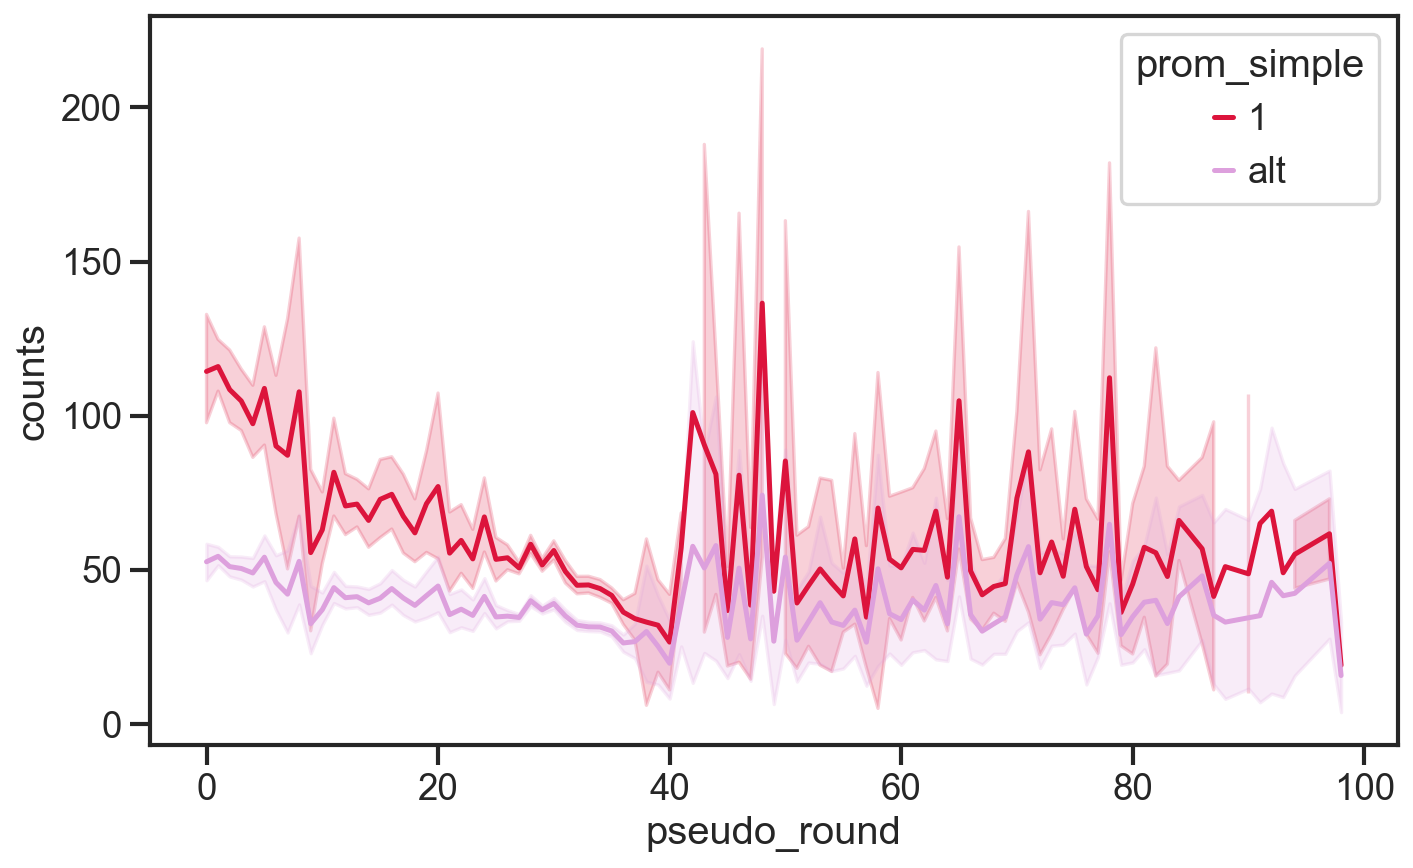

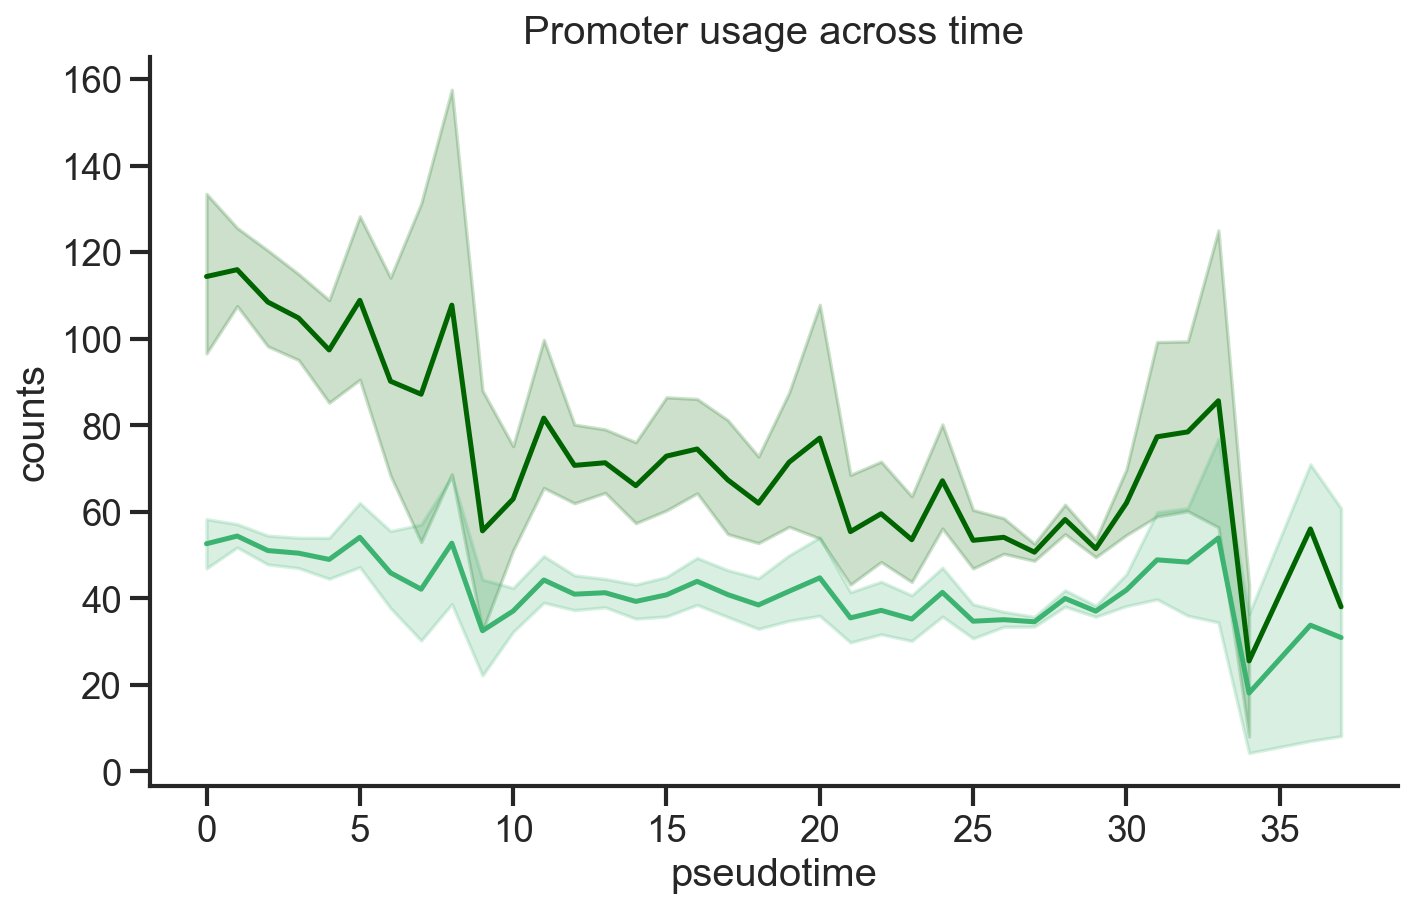

In [467]:
#fig, ax = plt.subplots(3,1, figsize=(10,6))
plt.figure(figsize=(10,6))

sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent','Ectoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['navy','cornflowerblue'],
            hue = 'prom_simple')
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent','Endoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['darkorange','goldenrod'],
            hue = 'prom_simple')

plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent','Mesoderm'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['crimson','plum'],
            hue = 'prom_simple')
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data = plot_hprom_pseudo[plot_hprom_pseudo['lineage'].isin( ['Pluripotent'])],
            x = 'pseudo_round',
            y = 'counts',
            palette = ['darkgreen','mediumseagreen'],
            hue = 'prom_simple')
plt.title('Promoter usage across time')
plt.xlabel('pseudotime')
plt.legend([],frameon=False)
#ax.set_ylim([0,1600])
sns.despine()
plt.show()





In [464]:
plot_hprom_pseudo

,promoter,cell,counts,hour,pseudo,lineage,pseudo_round,prom_simple
1,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_2,70.0,72h,27.279612,Pluripotent,27.0,1
2,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_3,59.0,72h,27.501333,Pluripotent,28.0,1
3,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_4,39.0,72h,15.200164,Pluripotent,15.0,1
4,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_5,84.0,72h,26.562374,Pluripotent,27.0,1
5,1,PZ-MB-TChIC-Gastd3-rep3-H3K4me3-1_6,50.0,72h,26.777443,Pluripotent,27.0,1
...,...,...,...,...,...,...,...,...
207700,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_379,3.0,mESCs,1.366939,Pluripotent,1.0,alt
207701,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_380,4.0,mESCs,0.605807,Pluripotent,1.0,alt
207702,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_381,1.0,mESCs,4.926665,Pluripotent,5.0,alt
207703,9,PZ-MB-TChIC-mESCs-rep4-H3K4me3-6_382,1.0,mESCs,0.662038,Pluripotent,1.0,alt
